# Notebook 31 — Negative-electrode plating-margin audit under DC–AC excitation

## Goal

Audit whether DC–AC protocols that show state-equivalent or event-level timing gains preserve negative-electrode plating margin.

The core question is:

> Do DC–AC protocols that reach equal Q earlier, or trigger voltage events earlier, remain admissible with respect to negative-electrode potential margin vs Li/Li+?

## Scientific context

Notebook 30 showed that DC–AC excitation can create equal-Q microstate differences, including electrolyte-gradient and negative-surface-state responses. However, in the tested Chen2020 DFN/SPMe/SPM hierarchy, raw Δt(Q) was geometry-dominated and Δt_resid(Q) remained close to zero.

Notebook 31 adds a safety/admissibility layer. The question is no longer only whether a protocol produces raw timing gain, but whether such gain remains within negative-electrode plating-margin constraints.

## Protocol / study design

Initial smoke audit:

- Parameter set: Chen2020
- Model: DFN
- Thermal setting: isothermal
- DC baseline: 0.3C
- DC–AC: 0.3C + 0.7C
- Frequency mode: set-rebased using Chen2020 tau2_biexp from Day17
- Frequency points: 0.5τ_set, 1.5τ_set, 3.0τ_set, 5.0τ_set

## Margin proxy

The intended plating-margin proxy is the negative-electrode surface potential difference vs Li/Li+:

```text
U_NE_vs_Li ≈ phi_s,n - phi_e,n
```

Audit classes:

| Class | Criterion |
|---|---|
| `safe_margin` | min U_NE_vs_Li > 50 mV |
| `near_boundary` | 0 mV < min U_NE_vs_Li <= 50 mV |
| `risk_flag` | min U_NE_vs_Li <= 0 mV |

The 50 mV threshold is an audit buffer, not a universal physical constant.

## Interpretation boundary

This notebook does not prove plating occurrence or absence. It audits a thermodynamic plating-margin proxy based on negative-electrode potential vs Li/Li+. A `risk_flag` means that the audit proxy crosses the selected threshold; it is not equivalent to confirmed lithium plating unless a plating submodel is enabled and plating current / plated lithium variables are explicitly evaluated.


In [1]:
# Cell 1 — Imports and project paths（导入库与项目路径）

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

from scipy.optimize import brentq

warnings.filterwarnings("default")

REPO = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "figures"
DOCS_TABLE_DIR = REPO / "docs" / "tables"
DOCS_FIG_DIR = REPO / "docs" / "figures"

for p in [DATA_DIR, FIG_DIR, DOCS_TABLE_DIR, DOCS_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("[OK] repo:", REPO)
print("[OK] pybamm version:", pybamm.__version__)
print("[OK] data dir:", DATA_DIR)


[OK] repo: /Users/louislu/pybamm-dcac-superimposed
[OK] pybamm version: 26.3.1
[OK] data dir: /Users/louislu/pybamm-dcac-superimposed/data


In [2]:
# Cell 2 — Load Chen2020 tau_ref and define Day31 smoke protocols（读取Chen2020时间常数并定义Day31冒烟工况）

PARAMETER_SET = "Chen2020"
MODEL_TYPE = "DFN"

DC_C = 0.3
AC_C = 0.7

tau_matrix_path = DATA_DIR / "day17_step1_tau_ref_descriptor_matrix.csv"
if not tau_matrix_path.exists():
    raise FileNotFoundError(tau_matrix_path)

tau_matrix_df = pd.read_csv(tau_matrix_path)

TAU_REF_SET_S = float(
    tau_matrix_df.loc[
        tau_matrix_df["param_set"] == PARAMETER_SET,
        "tau2_biexp"
    ].iloc[0]
)

print("[OK] tau_ref_set_s:", TAU_REF_SET_S)

def f_from_tau_factor_set(tau_factor, tau_ref_s=TAU_REF_SET_S):
    return 1.0 / (2.0 * np.pi * tau_factor * tau_ref_s)

def label_from_tau_factor_set(tau_factor):
    return str(tau_factor).replace(".", "p") + "tauSet"

TAU_FACTORS_SMOKE = [0.5, 1.5, 3.0, 5.0]

rows = []

rows.append({
    "parameter_set": PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "condition": "Chen2020_DFN_DC03",
    "protocol_type": "DC",
    "dc_c": DC_C,
    "ac_c": 0.0,
    "tau_factor_set": np.nan,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_Hz": np.nan,
    "period_s": np.nan,
    "omega_tau_set": np.nan,
    "kappa": 0.0,
})

for tau_factor in TAU_FACTORS_SMOKE:
    f_hz = f_from_tau_factor_set(tau_factor)
    period_s = 1.0 / f_hz
    rows.append({
        "parameter_set": PARAMETER_SET,
        "model_type": MODEL_TYPE,
        "condition": f"Chen2020_DFN_DC03_AC07_{label_from_tau_factor_set(tau_factor)}",
        "protocol_type": "DCAC",
        "dc_c": DC_C,
        "ac_c": AC_C,
        "tau_factor_set": tau_factor,
        "tau_ref_set_s": TAU_REF_SET_S,
        "f_Hz": f_hz,
        "period_s": period_s,
        "omega_tau_set": 1.0 / tau_factor,
        "kappa": AC_C / DC_C,
    })

protocol_df = pd.DataFrame(rows)

out = DATA_DIR / "day31_protocol_table_smoke.csv"
protocol_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(protocol_df)


[OK] tau_ref_set_s: 36.316532231592305
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_protocol_table_smoke.csv


,parameter_set,model_type,condition,protocol_type,dc_c,ac_c,tau_factor_set,tau_ref_set_s,f_Hz,period_s,omega_tau_set,kappa
0,Chen2020,DFN,Chen2020_DFN_DC03,DC,0.3,0.0,NaN,36.316532,NaN,NaN,NaN,0.000000
1,Chen2020,DFN,Chen2020_DFN_DC03_AC07_0p5tauSet,DCAC,0.3,0.7,0.5,36.316532,0.008765,114.091751,2.000000,2.333333
2,Chen2020,DFN,Chen2020_DFN_DC03_AC07_1p5tauSet,DCAC,0.3,0.7,1.5,36.316532,0.002922,342.275253,0.666667,2.333333
3,Chen2020,DFN,Chen2020_DFN_DC03_AC07_3p0tauSet,DCAC,0.3,0.7,3.0,36.316532,0.001461,684.550505,0.333333,2.333333
4,Chen2020,DFN,Chen2020_DFN_DC03_AC07_5p0tauSet,DCAC,0.3,0.7,5.0,36.316532,0.000876,1140.917509,0.200000,2.333333


In [3]:
# Cell 3 — Charge-first protocol builder and simulation wrapper（实验一致相位协议构建与仿真封装）

def make_model(model_type="DFN"):
    if model_type == "DFN":
        return pybamm.lithium_ion.DFN({"thermal": "isothermal"})
    if model_type == "SPMe":
        return pybamm.lithium_ion.SPMe({"thermal": "isothermal"})
    if model_type == "SPM":
        return pybamm.lithium_ion.SPM({"thermal": "isothermal"})
    raise ValueError(f"Unknown model_type: {model_type}")


def make_parameter_values_with_current(parameter_set, dc_c, ac_c, f_hz):
    pv = pybamm.ParameterValues(parameter_set)
    q_ah = float(pv["Nominal cell capacity [A.h]"])

    i_dc_abs = dc_c * q_ah
    i_ac_abs = ac_c * q_ah

    if ac_c == 0 or f_hz is None or pd.isna(f_hz):
        def current_fun(t):
            return -i_dc_abs + 0 * t
    else:
        def current_fun(t):
            return -i_dc_abs - i_ac_abs * pybamm.sin(2 * np.pi * f_hz * t)

    pv.update({"Current function [A]": current_fun}, check_already_exists=False)

    meta = {
        "parameter_set": parameter_set,
        "nominal_capacity_Ah": q_ah,
        "dc_c": dc_c,
        "ac_c": ac_c,
        "i_dc_A": i_dc_abs,
        "i_ac_A": i_ac_abs,
        "f_Hz": f_hz,
        "phase_convention": "charge_first",
        "pybamm_current": "I_py = -I_DC - I_AC*sin(2*pi*f*t)",
    }
    return pv, meta


def cumulative_trapezoid_np(y, x):
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    if len(y) != len(x):
        raise ValueError("x and y length mismatch")
    if len(y) < 2:
        return np.zeros_like(y)
    dx = np.diff(x)
    area = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(area)])


def extract_basic_timeseries(sol):
    t = np.asarray(sol.t, dtype=float)
    I_py = np.asarray(sol["Current [A]"](t), dtype=float).reshape(-1)
    V = np.asarray(sol["Terminal voltage [V]"](t), dtype=float).reshape(-1)

    I_charge = -I_py
    Q_Ah = cumulative_trapezoid_np(I_charge, t) / 3600.0

    return pd.DataFrame({
        "t_s": t,
        "I_py_A": I_py,
        "I_charge_A": I_charge,
        "V_terminal_V": V,
        "Q_net_Ah": Q_Ah,
    })


def run_simulation(protocol_row, initial_soc=0.05, max_time_s=24000, n_eval=5000):
    model = make_model(protocol_row["model_type"])
    pv, meta = make_parameter_values_with_current(
        parameter_set=protocol_row["parameter_set"],
        dc_c=float(protocol_row["dc_c"]),
        ac_c=float(protocol_row["ac_c"]),
        f_hz=None if pd.isna(protocol_row["f_Hz"]) else float(protocol_row["f_Hz"]),
    )

    sim = pybamm.Simulation(model, parameter_values=pv)
    t_eval = np.linspace(0.0, max_time_s, n_eval)
    sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
    ts = extract_basic_timeseries(sol)

    return sim, sol, ts, meta

print("[OK] simulation utilities ready")


[OK] simulation utilities ready


In [4]:
# Cell 4 — Run Chen2020 DFN plating-margin smoke simulations（运行Chen2020 DFN析锂余量冒烟仿真）

solutions = {}
run_rows = []

for _, row in protocol_df.iterrows():
    cond = row["condition"]
    print(f"\n[RUN] {cond}")

    try:
        sim, sol, ts, meta = run_simulation(row.to_dict())
        solutions[cond] = {
            "sim": sim,
            "sol": sol,
            "ts": ts,
            "meta": meta,
            "protocol": row.to_dict(),
        }

        run_rows.append({
            "condition": cond,
            "status": "ok",
            "termination": str(sol.termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "error": "",
        })
        print("[OK]", cond, "| termination:", sol.termination)
    except Exception as e:
        run_rows.append({
            "condition": cond,
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

run_summary_df = pd.DataFrame(run_rows)

out = DATA_DIR / "day31_run_summary_smoke.csv"
run_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(run_summary_df)



[RUN] Chen2020_DFN_DC03
[OK] Chen2020_DFN_DC03 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC07_0p5tauSet
[OK] Chen2020_DFN_DC03_AC07_0p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC07_1p5tauSet
[OK] Chen2020_DFN_DC03_AC07_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC07_3p0tauSet
[OK] Chen2020_DFN_DC03_AC07_3p0tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC07_5p0tauSet
[OK] Chen2020_DFN_DC03_AC07_5p0tauSet | termination: event: Maximum voltage [V]
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_run_summary_smoke.csv


,condition,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,error
0,Chen2020_DFN_DC03,ok,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000,1.5,
1,Chen2020_DFN_DC03_AC07_0p5tauSet,ok,event: Maximum voltage [V],8816.441612,146.940694,3.693538,4.2,-2.000000,5.0,
2,Chen2020_DFN_DC03_AC07_1p5tauSet,ok,event: Maximum voltage [V],8627.912611,143.798544,3.633942,4.2,-2.000000,5.0,
3,Chen2020_DFN_DC03_AC07_3p0tauSet,ok,event: Maximum voltage [V],8356.422363,139.273706,3.559599,4.2,-2.000000,5.0,
4,Chen2020_DFN_DC03_AC07_5p0tauSet,ok,event: Maximum voltage [V],8207.258608,136.787643,3.534928,4.2,-1.999999,5.0,


In [5]:
# Cell 5 — Variable availability audit for negative-electrode plating margin（负极析锂余量变量可用性审计）

rep_cond = "Chen2020_DFN_DC03"
rep_sim = solutions[rep_cond]["sim"]

all_keys = sorted(list(rep_sim.built_model.variables.keys()))

search_terms = [
    "surface potential difference",
    "negative electrode potential",
    "negative electrode surface potential",
    "electrolyte potential",
    "lithium plating",
    "plating",
    "reaction overpotential",
    "open-circuit potential",
]

availability_rows = []

for term in search_terms:
    matches = [k for k in all_keys if term.lower() in k.lower()]
    for m in matches:
        availability_rows.append({
            "search_term": term,
            "variable_key": m,
        })

availability_df = pd.DataFrame(availability_rows)

out = DATA_DIR / "day31_variable_availability_plating_margin_smoke.csv"
availability_df.to_csv(out, index=False)

print("[OK] saved:", out)
print("[INFO] matches:", len(availability_df))
display(availability_df.head(250))


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_variable_availability_plating_margin_smoke.csv
[INFO] matches: 104


,search_term,variable_key
0,surface potential difference,Negative electrode surface potential differenc...
1,surface potential difference,Negative electrode surface potential differenc...
2,surface potential difference,Positive electrode surface potential differenc...
3,surface potential difference,Positive electrode surface potential differenc...
4,surface potential difference,X-averaged negative electrode surface potentia...
...,...,...
99,open-circuit potential,Positive electrode open-circuit potential [V]
100,open-circuit potential,X-averaged negative electrode equilibrium open...
101,open-circuit potential,X-averaged negative electrode open-circuit pot...
102,open-circuit potential,X-averaged positive electrode equilibrium open...


In [6]:
# Cell 5B — Print full negative-electrode potential candidate keys（打印完整负极电位候选变量名）

pd.set_option("display.max_colwidth", 200)

candidate_terms = [
    "negative electrode surface potential difference",
    "x-averaged negative electrode surface potential difference",
    "minimum negative electrode surface potential difference",
    "negative electrode potential",
    "electrolyte potential",
    "lithium plating",
    "plating",
]

candidate_keys = []

for term in candidate_terms:
    matches = [k for k in all_keys if term.lower() in k.lower()]
    print(f"\n[TERM] {term} — {len(matches)} matches")
    for k in matches:
        print("  ", k)
        candidate_keys.append(k)

candidate_keys = sorted(set(candidate_keys))

candidate_key_df = pd.DataFrame({"variable_key": candidate_keys})
out = DATA_DIR / "day31_plating_margin_candidate_keys_smoke.csv"
candidate_key_df.to_csv(out, index=False)

print("\n[OK] saved:", out)
display(candidate_key_df)


[TERM] negative electrode surface potential difference — 3 matches
   Negative electrode surface potential difference [V]
   Negative electrode surface potential difference at separator interface [V]
   X-averaged negative electrode surface potential difference [V]

[TERM] x-averaged negative electrode surface potential difference — 1 matches
   X-averaged negative electrode surface potential difference [V]

[TERM] minimum negative electrode surface potential difference — 0 matches

[TERM] negative electrode potential — 3 matches
   Gradient of negative electrode potential [V.m-1]
   Negative electrode potential [V]
   X-averaged negative electrode potential [V]

[TERM] electrolyte potential — 12 matches
   Electrolyte potential [V]
   Gradient of electrolyte potential [V.m-1]
   Gradient of negative electrolyte potential [V.m-1]
   Gradient of positive electrolyte potential [V.m-1]
   Gradient of separator electrolyte potential [V.m-1]
   Negative electrolyte potential [V]
   Positiv

,variable_key
0,Electrolyte potential [V]
1,Gradient of electrolyte potential [V.m-1]
2,Gradient of negative electrode potential [V.m-1]
3,Gradient of negative electrolyte potential [V.m-1]
4,Gradient of positive electrolyte potential [V.m-1]
5,Gradient of separator electrolyte potential [V.m-1]
6,Loss of capacity to negative lithium plating [A.h]
7,Loss of capacity to positive lithium plating [A.h]
8,Loss of lithium to negative lithium plating [mol]
9,Loss of lithium to positive lithium plating [mol]


In [7]:
# Cell 6 — Extract negative-electrode plating-margin proxy（提取负极析锂余量代理变量）

PLATING_MARGIN_SAFE_BUFFER_V = 0.050  # 50 mV audit buffer, not a universal physical constant

NE_SURFACE_KEY = "Negative electrode surface potential difference [V]"
NE_SEPARATOR_KEY = "Negative electrode surface potential difference at separator interface [V]"
NE_XAVG_KEY = "X-averaged negative electrode surface potential difference [V]"

def reduce_variable_to_timeseries(arr, t_s, reducer="mean"):
    arr = np.asarray(arr, dtype=float)
    t_s = np.asarray(t_s, dtype=float)
    n_t = len(t_s)
    
    if arr.ndim == 0:
        return np.full(n_t, float(arr))
    
    if arr.ndim == 1:
        if arr.shape[0] == n_t:
            return arr
        return np.full(n_t, np.nanmean(arr))
    
    # time last: (..., n_t)
    if arr.shape[-1] == n_t:
        flat = arr.reshape(-1, n_t)
        axis = 0
    # time first: (n_t, ...)
    elif arr.shape[0] == n_t:
        flat = arr.reshape(n_t, -1)
        axis = 1
    else:
        raise ValueError(f"Cannot identify time axis: arr.shape={arr.shape}, n_t={n_t}")
    
    if reducer == "min":
        return np.nanmin(flat, axis=axis)
    if reducer == "max":
        return np.nanmax(flat, axis=axis)
    if reducer == "mean":
        return np.nanmean(flat, axis=axis)
    
    raise ValueError(f"Unknown reducer: {reducer}")

def classify_margin(u_v):
    if pd.isna(u_v):
        return "unresolved"
    if u_v <= 0.0:
        return "risk_flag"
    if u_v <= PLATING_MARGIN_SAFE_BUFFER_V:
        return "near_boundary"
    return "safe_margin"

margin_ts_map = {}
margin_audit_rows = []

for cond, obj in solutions.items():
    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()
    
    raw_surface = sol[NE_SURFACE_KEY](t_s)
    raw_surface_arr = np.asarray(raw_surface)
    
    ts["U_NE_vs_Li_min_V"] = reduce_variable_to_timeseries(
        raw_surface_arr,
        t_s,
        reducer="min",
    )
    
    ts["U_NE_vs_Li_mean_V"] = reduce_variable_to_timeseries(
        raw_surface_arr,
        t_s,
        reducer="mean",
    )
    
    raw_sep = sol[NE_SEPARATOR_KEY](t_s)
    raw_sep_arr = np.asarray(raw_sep)
    ts["U_NE_vs_Li_separator_V"] = reduce_variable_to_timeseries(
        raw_sep_arr,
        t_s,
        reducer="mean",
    )
    
    raw_xavg = sol[NE_XAVG_KEY](t_s)
    raw_xavg_arr = np.asarray(raw_xavg)
    ts["U_NE_vs_Li_xavg_V"] = reduce_variable_to_timeseries(
        raw_xavg_arr,
        t_s,
        reducer="mean",
    )
    
    ts["U_NE_margin_min_mV"] = ts["U_NE_vs_Li_min_V"] * 1000.0
    ts["U_NE_margin_separator_mV"] = ts["U_NE_vs_Li_separator_V"] * 1000.0
    ts["margin_class_inst"] = ts["U_NE_vs_Li_min_V"].apply(classify_margin)
    
    margin_ts_map[cond] = ts
    
    margin_audit_rows.append({
        "condition": cond,
        "surface_key": NE_SURFACE_KEY,
        "surface_shape": str(raw_surface_arr.shape),
        "separator_key": NE_SEPARATOR_KEY,
        "separator_shape": str(raw_sep_arr.shape),
        "xavg_key": NE_XAVG_KEY,
        "xavg_shape": str(raw_xavg_arr.shape),
        "status": "ok",
    })

margin_extraction_audit_df = pd.DataFrame(margin_audit_rows)

out = DATA_DIR / "day31_plating_margin_extraction_audit_smoke.csv"
margin_extraction_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(margin_extraction_audit_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_plating_margin_extraction_audit_smoke.csv


,condition,surface_key,surface_shape,separator_key,separator_shape,xavg_key,xavg_shape,status
0,Chen2020_DFN_DC03,Negative electrode surface potential difference [V],"(22, 12159)",Negative electrode surface potential difference at separator interface [V],"(12159,)",X-averaged negative electrode surface potential difference [V],"(12159,)",ok
1,Chen2020_DFN_DC03_AC07_0p5tauSet,Negative electrode surface potential difference [V],"(22, 18735)",Negative electrode surface potential difference at separator interface [V],"(18735,)",X-averaged negative electrode surface potential difference [V],"(18735,)",ok
2,Chen2020_DFN_DC03_AC07_1p5tauSet,Negative electrode surface potential difference [V],"(22, 14885)",Negative electrode surface potential difference at separator interface [V],"(14885,)",X-averaged negative electrode surface potential difference [V],"(14885,)",ok
3,Chen2020_DFN_DC03_AC07_3p0tauSet,Negative electrode surface potential difference [V],"(22, 13049)",Negative electrode surface potential difference at separator interface [V],"(13049,)",X-averaged negative electrode surface potential difference [V],"(13049,)",ok
4,Chen2020_DFN_DC03_AC07_5p0tauSet,Negative electrode surface potential difference [V],"(22, 11933)",Negative electrode surface potential difference at separator interface [V],"(11933,)",X-averaged negative electrode surface potential difference [V],"(11933,)",ok


In [8]:
# Cell 7 — Protocol-level plating-margin summary（协议级析锂余量摘要）

summary_rows = []

for _, pr in protocol_df.iterrows():
    cond = pr["condition"]
    ts = margin_ts_map[cond]
    
    idx_min = int(ts["U_NE_vs_Li_min_V"].idxmin())
    row_min = ts.loc[idx_min]
    
    min_u = float(row_min["U_NE_vs_Li_min_V"])
    sep_min = float(ts["U_NE_vs_Li_separator_V"].min())
    xavg_min = float(ts["U_NE_vs_Li_xavg_V"].min())
    
    summary_rows.append({
        "parameter_set": pr["parameter_set"],
        "model_type": pr["model_type"],
        "condition": cond,
        "protocol_type": pr["protocol_type"],
        "dc_c": pr["dc_c"],
        "ac_c": pr["ac_c"],
        "tau_factor_set": pr["tau_factor_set"],
        "f_Hz": pr["f_Hz"],
        "period_s": pr["period_s"],
        "t_end_s": float(ts["t_s"].iloc[-1]),
        "t_end_min": float(ts["t_s"].iloc[-1] / 60.0),
        "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
        "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
        "min_U_NE_vs_Li_V": min_u,
        "min_U_NE_vs_Li_mV": min_u * 1000.0,
        "min_U_NE_separator_V": sep_min,
        "min_U_NE_separator_mV": sep_min * 1000.0,
        "min_U_NE_xavg_V": xavg_min,
        "min_U_NE_xavg_mV": xavg_min * 1000.0,
        "t_at_min_U_NE_s": float(row_min["t_s"]),
        "Q_at_min_U_NE_Ah": float(row_min["Q_net_Ah"]),
        "I_charge_at_min_U_NE_A": float(row_min["I_charge_A"]),
        "fraction_time_below_50mV": float((ts["U_NE_vs_Li_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_vs_Li_min_V"] <= 0.0).mean()),
        "margin_class": classify_margin(min_u),
    })

protocol_margin_summary_df = pd.DataFrame(summary_rows)

out = DATA_DIR / "day31_protocol_plating_margin_summary_smoke.csv"
protocol_margin_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(protocol_margin_summary_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_protocol_plating_margin_summary_smoke.csv


,parameter_set,model_type,condition,protocol_type,dc_c,ac_c,tau_factor_set,f_Hz,period_s,t_end_s,...,min_U_NE_separator_V,min_U_NE_separator_mV,min_U_NE_xavg_V,min_U_NE_xavg_mV,t_at_min_U_NE_s,Q_at_min_U_NE_Ah,I_charge_at_min_U_NE_A,fraction_time_below_50mV,fraction_time_below_0mV,margin_class
0,Chen2020,DFN,Chen2020_DFN_DC03,DC,0.3,0.0,NaN,NaN,NaN,10782.909607,...,0.037917,37.917452,0.046710,46.709659,10782.909607,4.492879,1.500000,0.219837,0.000000,near_boundary
1,Chen2020,DFN,Chen2020_DFN_DC03_AC07_0p5tauSet,DCAC,0.3,0.7,0.5,0.008765,114.091751,8816.441612,...,-0.016392,-16.392230,0.003396,3.396374,8816.441612,3.693538,4.956862,0.196904,0.027756,risk_flag
2,Chen2020,DFN,Chen2020_DFN_DC03_AC07_1p5tauSet,DCAC,0.3,0.7,1.5,0.002922,342.275253,8627.912611,...,-0.023360,-23.359654,0.001830,1.830032,8309.072266,3.523668,4.953419,0.222304,0.039973,risk_flag
3,Chen2020,DFN,Chen2020_DFN_DC03_AC07_3p0tauSet,DCAC,0.3,0.7,3.0,0.001461,684.550505,8356.422363,...,-0.022918,-22.918083,0.002076,2.076228,8356.422363,3.559599,4.874011,0.231359,0.040233,risk_flag
4,Chen2020,DFN,Chen2020_DFN_DC03_AC07_5p0tauSet,DCAC,0.3,0.7,5.0,0.000876,1140.917509,8207.258608,...,-0.021865,-21.864586,0.003164,3.164494,8207.258608,3.534928,4.782222,0.253666,0.040141,risk_flag


In [10]:
# Cell 7B — Display compact protocol margin summary（显示紧凑协议级析锂余量摘要）

compact_margin_cols = [
    "condition",
    "protocol_type",
    "tau_factor_set",
    "t_end_min",
    "Q_end_Ah",
    "min_U_NE_vs_Li_mV",
    "min_U_NE_separator_mV",
    "min_U_NE_xavg_mV",
    "t_at_min_U_NE_s",
    "Q_at_min_U_NE_Ah",
    "I_charge_at_min_U_NE_A",
    "fraction_time_below_50mV",
    "fraction_time_below_0mV",
    "margin_class",
]

display(protocol_margin_summary_df[compact_margin_cols])

,condition,protocol_type,tau_factor_set,t_end_min,Q_end_Ah,min_U_NE_vs_Li_mV,min_U_NE_separator_mV,min_U_NE_xavg_mV,t_at_min_U_NE_s,Q_at_min_U_NE_Ah,I_charge_at_min_U_NE_A,fraction_time_below_50mV,fraction_time_below_0mV,margin_class
0,Chen2020_DFN_DC03,DC,NaN,179.715160,4.492879,37.280562,37.917452,46.709659,10782.909607,4.492879,1.500000,0.219837,0.000000,near_boundary
1,Chen2020_DFN_DC03_AC07_0p5tauSet,DCAC,0.5,146.940694,3.693538,-17.980759,-16.392230,3.396374,8816.441612,3.693538,4.956862,0.196904,0.027756,risk_flag
2,Chen2020_DFN_DC03_AC07_1p5tauSet,DCAC,1.5,143.798544,3.633942,-25.298691,-23.359654,1.830032,8309.072266,3.523668,4.953419,0.222304,0.039973,risk_flag
3,Chen2020_DFN_DC03_AC07_3p0tauSet,DCAC,3.0,139.273706,3.559599,-24.834389,-22.918083,2.076228,8356.422363,3.559599,4.874011,0.231359,0.040233,risk_flag
4,Chen2020_DFN_DC03_AC07_5p0tauSet,DCAC,5.0,136.787643,3.534928,-23.775308,-21.864586,3.164494,8207.258608,3.534928,4.782222,0.253666,0.040141,risk_flag


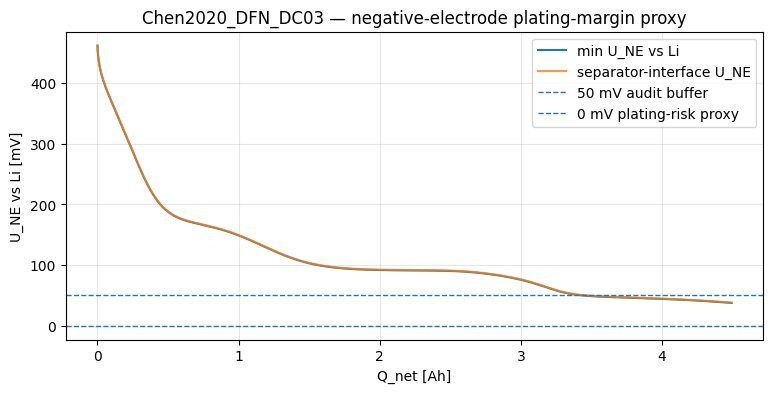

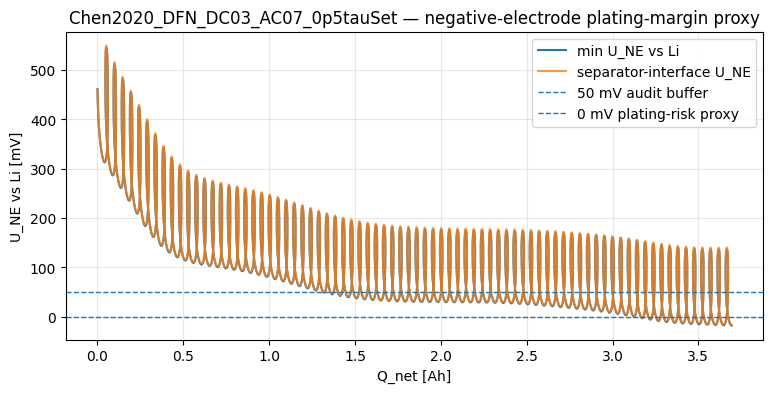

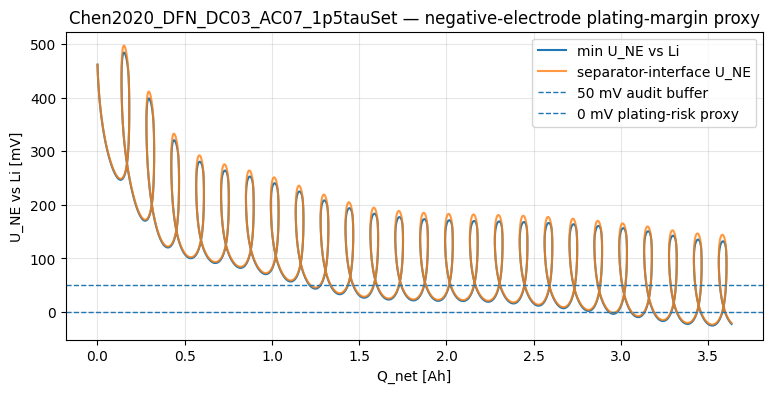

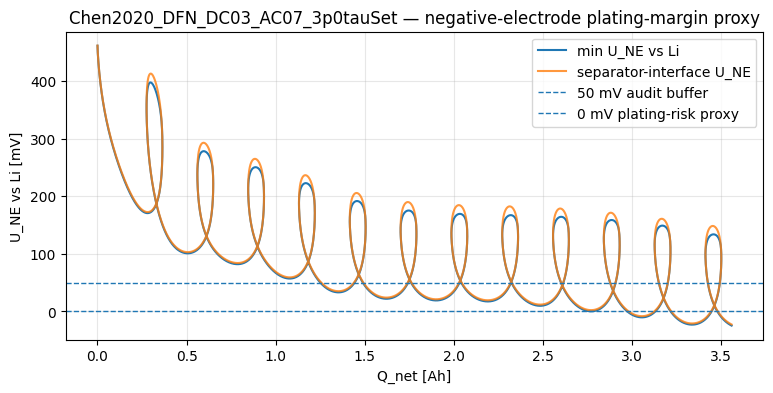

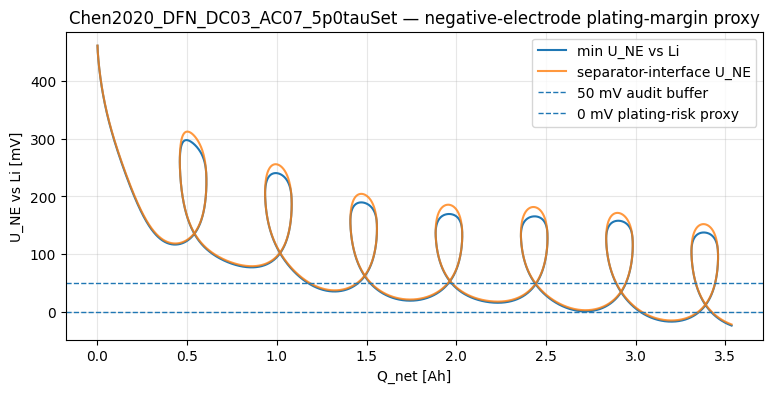

In [9]:
# Cell 8 — Plot negative-electrode plating-margin proxy（绘制负极析锂余量代理变量）

for cond, ts in margin_ts_map.items():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ts["Q_net_Ah"], ts["U_NE_vs_Li_min_V"] * 1000, label="min U_NE vs Li")
    ax.plot(ts["Q_net_Ah"], ts["U_NE_vs_Li_separator_V"] * 1000, label="separator-interface U_NE", alpha=0.8)
    ax.axhline(50, linestyle="--", linewidth=1, label="50 mV audit buffer")
    ax.axhline(0, linestyle="--", linewidth=1, label="0 mV plating-risk proxy")
    ax.set_xlabel("Q_net [Ah]")
    ax.set_ylabel("U_NE vs Li [mV]")
    ax.set_title(f"{cond} — negative-electrode plating-margin proxy")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

In [11]:
# Cell 9 — Equal-Q plating-margin curves（等Q负极析锂余量曲线）

def first_passage_time(t_s, q_Ah, q_target_Ah):
    t_s = np.asarray(t_s, dtype=float)
    q_Ah = np.asarray(q_Ah, dtype=float)
    hit = np.where(q_Ah >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan
    i = int(hit[0])
    if i == 0:
        return float(t_s[0])
    q0, q1 = q_Ah[i - 1], q_Ah[i]
    t0, t1 = t_s[i - 1], t_s[i]
    if q1 == q0:
        return float(t1)
    frac = (q_target_Ah - q0) / (q1 - q0)
    return float(t0 + frac * (t1 - t0))

def interp_at_time(t_s, y, t_target):
    if np.isnan(t_target):
        return np.nan
    return float(np.interp(t_target, t_s, y))

# Build common Q grid across all protocols
q_end_by_cond = {
    cond: float(ts["Q_net_Ah"].max())
    for cond, ts in margin_ts_map.items()
}
q_hi_raw = min(q_end_by_cond.values())
q_lo = 0.2
q_hi = 0.95 * q_hi_raw
q_grid = np.linspace(q_lo, q_hi, 100)

print("[OK] q_end_by_cond:")
for k, v in q_end_by_cond.items():
    print(f"  {k}: {v:.6f} Ah")
print(f"[OK] common Q grid: {q_grid[0]:.6f} → {q_grid[-1]:.6f} Ah, n={len(q_grid)}")

equalq_rows = []

for _, pr in protocol_df.iterrows():
    cond = pr["condition"]
    ts = margin_ts_map[cond]
    t_arr = ts["t_s"].to_numpy()
    q_arr = ts["Q_net_Ah"].to_numpy()
    
    for q in q_grid:
        t_q = first_passage_time(t_arr, q_arr, q)
        
        rec = {
            "condition": cond,
            "protocol_type": pr["protocol_type"],
            "tau_factor_set": pr["tau_factor_set"],
            "Q_Ah": float(q),
            "Q_frac_of_common_hi": float(q / q_hi),
            "t_q_s": t_q,
            "U_NE_min_V": interp_at_time(t_arr, ts["U_NE_vs_Li_min_V"].to_numpy(), t_q),
            "U_NE_separator_V": interp_at_time(t_arr, ts["U_NE_vs_Li_separator_V"].to_numpy(), t_q),
            "U_NE_xavg_V": interp_at_time(t_arr, ts["U_NE_vs_Li_xavg_V"].to_numpy(), t_q),
            "I_charge_A": interp_at_time(t_arr, ts["I_charge_A"].to_numpy(), t_q),
            "V_terminal_V": interp_at_time(t_arr, ts["V_terminal_V"].to_numpy(), t_q),
        }
        rec["U_NE_min_mV"] = rec["U_NE_min_V"] * 1000.0
        rec["margin_class_at_Q"] = classify_margin(rec["U_NE_min_V"])
        equalq_rows.append(rec)

equalq_margin_df = pd.DataFrame(equalq_rows)

out = DATA_DIR / "day31_equalQ_plating_margin_curves_smoke.csv"
equalq_margin_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(equalq_margin_df.head())

[OK] q_end_by_cond:
  Chen2020_DFN_DC03: 4.492879 Ah
  Chen2020_DFN_DC03_AC07_0p5tauSet: 3.693538 Ah
  Chen2020_DFN_DC03_AC07_1p5tauSet: 3.633942 Ah
  Chen2020_DFN_DC03_AC07_3p0tauSet: 3.559599 Ah
  Chen2020_DFN_DC03_AC07_5p0tauSet: 3.534928 Ah
[OK] common Q grid: 0.200000 → 3.358182 Ah, n=100
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_equalQ_plating_margin_curves_smoke.csv


,condition,protocol_type,tau_factor_set,Q_Ah,Q_frac_of_common_hi,t_q_s,U_NE_min_V,U_NE_separator_V,U_NE_xavg_V,I_charge_A,V_terminal_V,U_NE_min_mV,margin_class_at_Q
0,Chen2020_DFN_DC03,DC,NaN,0.200000,0.059556,480.000000,0.314692,0.315328,0.324155,1.5,3.360800,314.692287,safe_margin
1,Chen2020_DFN_DC03,DC,NaN,0.231901,0.069055,556.561986,0.296908,0.297544,0.306392,1.5,3.381975,296.907989,safe_margin
2,Chen2020_DFN_DC03,DC,NaN,0.263802,0.078555,633.123971,0.278999,0.279635,0.288492,1.5,3.403178,278.998674,safe_margin
3,Chen2020_DFN_DC03,DC,NaN,0.295702,0.088054,709.685957,0.261470,0.262106,0.270959,1.5,3.423927,261.469735,safe_margin
4,Chen2020_DFN_DC03,DC,NaN,0.327603,0.097554,786.247943,0.244935,0.245571,0.254409,1.5,3.443624,244.934992,safe_margin


In [12]:
# Cell 10 — Equal-Q margin difference relative to DC baseline（相对DC基线的等Q余量差异）

DC_COND = "Chen2020_DFN_DC03"

dc_eq = equalq_margin_df[equalq_margin_df["condition"] == DC_COND].copy()
dc_eq = dc_eq.set_index("Q_Ah")

delta_margin_rows = []

for cond, g in equalq_margin_df.groupby("condition"):
    if cond == DC_COND:
        continue
    
    ac_eq = g.set_index("Q_Ah")
    
    for q in q_grid:
        q = float(q)
        dc_row = dc_eq.loc[q]
        ac_row = ac_eq.loc[q]
        
        delta_margin_rows.append({
            "condition": cond,
            "reference_condition": DC_COND,
            "tau_factor_set": ac_row["tau_factor_set"],
            "Q_Ah": q,
            "t_DC_s": float(dc_row["t_q_s"]),
            "t_DCAC_s": float(ac_row["t_q_s"]),
            "delta_t_raw_s": float(dc_row["t_q_s"] - ac_row["t_q_s"]),
            "U_NE_min_DC_mV": float(dc_row["U_NE_min_mV"]),
            "U_NE_min_DCAC_mV": float(ac_row["U_NE_min_mV"]),
            "delta_U_NE_min_mV": float(ac_row["U_NE_min_mV"] - dc_row["U_NE_min_mV"]),
            "I_charge_DCAC_A": float(ac_row["I_charge_A"]),
            "margin_class_DCAC_at_Q": ac_row["margin_class_at_Q"],
        })

delta_margin_df = pd.DataFrame(delta_margin_rows)

out = DATA_DIR / "day31_equalQ_plating_margin_delta_vs_DC_smoke.csv"
delta_margin_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(delta_margin_df.head(20))

# Summary
equalq_margin_summary_df = (
    delta_margin_df
    .groupby(["condition", "tau_factor_set"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        U_NE_min_DCAC_min_mV=("U_NE_min_DCAC_mV", "min"),
        U_NE_min_DCAC_mean_mV=("U_NE_min_DCAC_mV", "mean"),
        delta_U_NE_min_mean_mV=("delta_U_NE_min_mV", "mean"),
        delta_U_NE_min_min_mV=("delta_U_NE_min_mV", "min"),
        fraction_Q_below_50mV=("U_NE_min_DCAC_mV", lambda x: np.mean(x <= 50.0)),
        fraction_Q_below_0mV=("U_NE_min_DCAC_mV", lambda x: np.mean(x <= 0.0)),
    )
)

equalq_margin_summary_df["equalQ_margin_class"] = equalq_margin_summary_df["U_NE_min_DCAC_min_mV"].apply(
    lambda x: classify_margin(x / 1000.0)
)

out = DATA_DIR / "day31_equalQ_plating_margin_summary_smoke.csv"
equalq_margin_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(equalq_margin_summary_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_equalQ_plating_margin_delta_vs_DC_smoke.csv


,condition,reference_condition,tau_factor_set,Q_Ah,t_DC_s,t_DCAC_s,delta_t_raw_s,U_NE_min_DC_mV,U_NE_min_DCAC_mV,delta_U_NE_min_mV,I_charge_DCAC_A,margin_class_DCAC_at_Q
0,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.200000,480.000000,396.067487,83.932513,314.692287,273.963684,-40.728603,2.123510,safe_margin
1,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.231901,556.561986,493.984770,62.577216,296.907989,209.046869,-87.861120,4.568078,safe_margin
2,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.263802,633.123971,596.547425,36.576547,278.998674,197.643590,-81.355084,4.967758,safe_margin
3,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.295702,709.685957,625.392332,84.293625,261.469735,228.521659,-32.948076,1.906192,safe_margin
4,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.327603,786.247943,722.677309,63.570634,244.934992,162.008533,-82.926459,4.519609,safe_margin
5,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.359504,862.809928,825.194254,37.615674,229.956842,152.430757,-77.526085,4.976664,safe_margin
6,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.391405,939.371914,854.868137,84.503776,216.918301,196.111584,-20.806717,1.657999,safe_margin
7,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.423306,1015.933899,951.369267,64.564633,205.969589,131.531528,-74.438062,4.470863,safe_margin
8,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.455207,1092.495885,1053.842623,38.653262,197.048264,124.983949,-72.064316,4.986148,safe_margin
9,Chen2020_DFN_DC03_AC07_0p5tauSet,Chen2020_DFN_DC03,0.5,0.487107,1169.057871,1084.592532,84.465339,189.943153,182.470756,-7.472397,1.361119,safe_margin


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_equalQ_plating_margin_summary_smoke.csv


,condition,tau_factor_set,delta_t_raw_mean_s,U_NE_min_DCAC_min_mV,U_NE_min_DCAC_mean_mV,delta_U_NE_min_mean_mV,delta_U_NE_min_min_mV,fraction_Q_below_50mV,fraction_Q_below_0mV,equalQ_margin_class
0,Chen2020_DFN_DC03_AC07_0p5tauSet,0.5,53.955332,-11.757727,65.576273,-53.849579,-87.861120,0.49,0.05,risk_flag
1,Chen2020_DFN_DC03_AC07_1p5tauSet,1.5,158.547038,-19.436998,54.386511,-65.039341,-108.631589,0.58,0.10,risk_flag
2,Chen2020_DFN_DC03_AC07_3p0tauSet,3.0,318.292354,-22.993038,52.415710,-67.010141,-120.025730,0.60,0.10,risk_flag
3,Chen2020_DFN_DC03_AC07_5p0tauSet,5.0,534.815258,-16.941312,51.084189,-68.341662,-117.553677,0.61,0.10,risk_flag


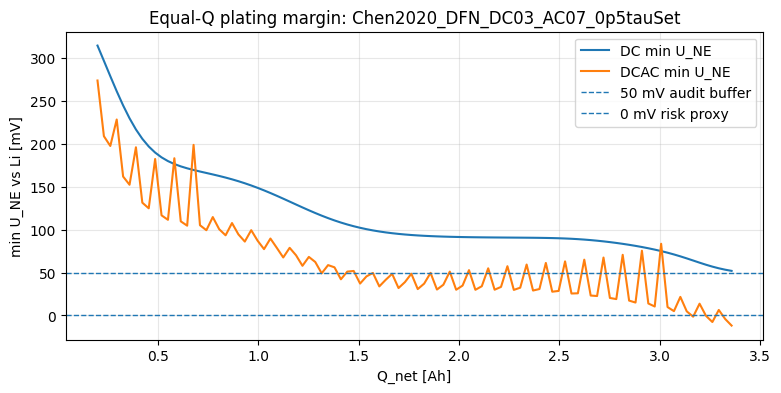

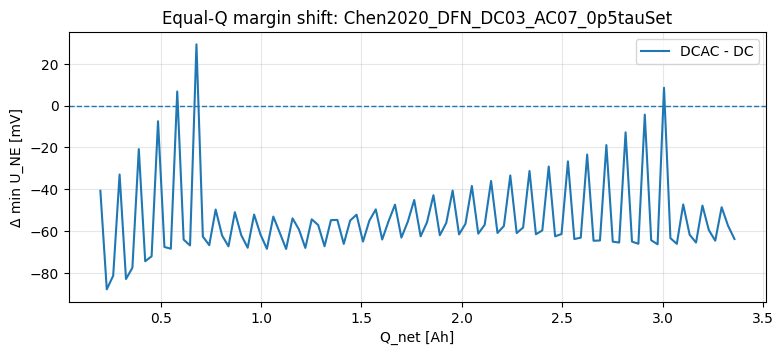

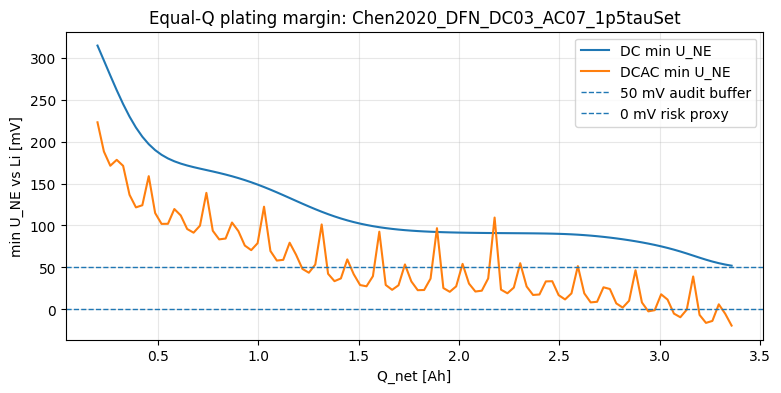

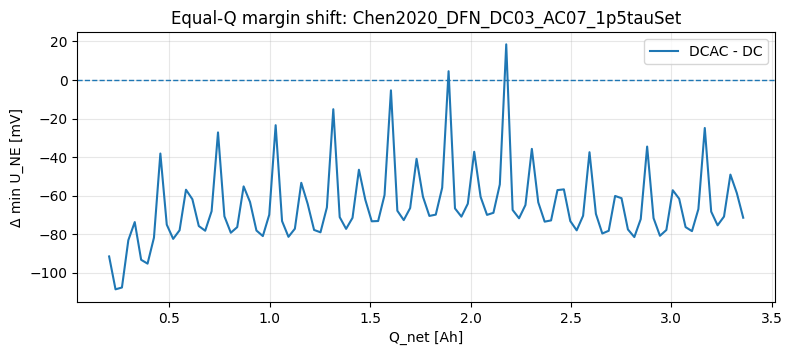

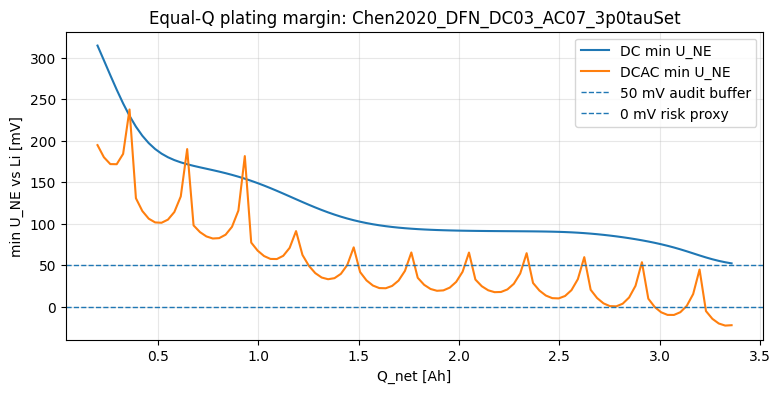

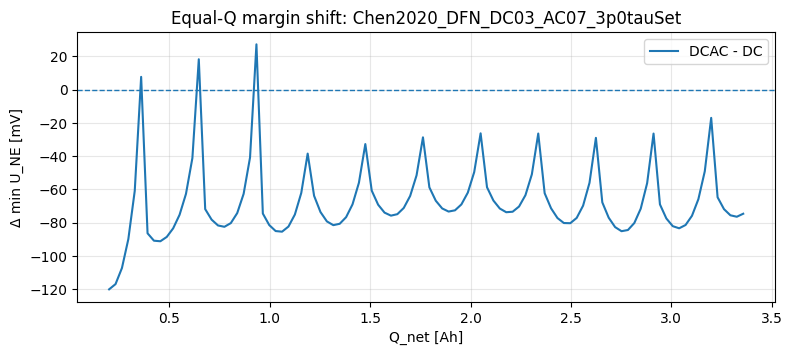

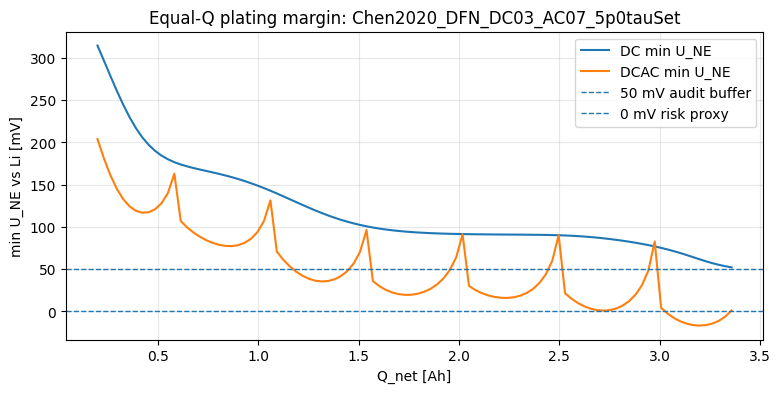

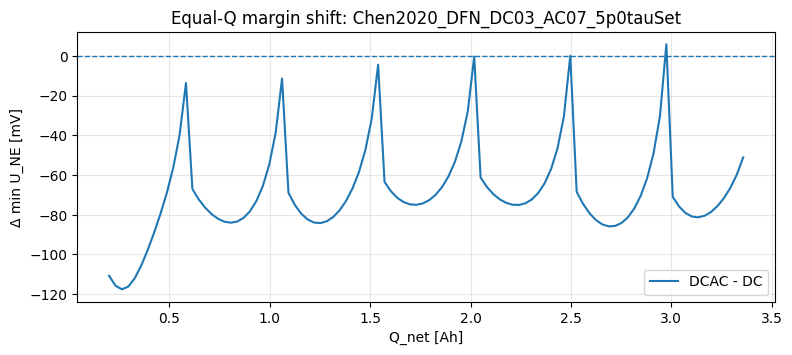

In [13]:
# Cell 11 — Plot equal-Q plating-margin comparison（绘制等Q负极余量对比）

for cond in protocol_df.loc[protocol_df["protocol_type"] == "DCAC", "condition"]:
    g = delta_margin_df[delta_margin_df["condition"] == cond].copy()
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(g["Q_Ah"], g["U_NE_min_DC_mV"], label="DC min U_NE")
    ax.plot(g["Q_Ah"], g["U_NE_min_DCAC_mV"], label="DCAC min U_NE")
    ax.axhline(50, linestyle="--", linewidth=1, label="50 mV audit buffer")
    ax.axhline(0, linestyle="--", linewidth=1, label="0 mV risk proxy")
    ax.set_xlabel("Q_net [Ah]")
    ax.set_ylabel("min U_NE vs Li [mV]")
    ax.set_title(f"Equal-Q plating margin: {cond}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()
    
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(g["Q_Ah"], g["delta_U_NE_min_mV"], label="DCAC - DC")
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("Q_net [Ah]")
    ax.set_ylabel("Δ min U_NE [mV]")
    ax.set_title(f"Equal-Q margin shift: {cond}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

In [14]:
# Cell 12 — Gain-margin admissibility ledger（时间收益-负极余量准入账本）

ledger_df = equalq_margin_summary_df.merge(
    protocol_margin_summary_df[
        [
            "condition",
            "t_end_min",
            "Q_end_Ah",
            "min_U_NE_vs_Li_mV",
            "min_U_NE_separator_mV",
            "min_U_NE_xavg_mV",
            "fraction_time_below_50mV",
            "fraction_time_below_0mV",
            "margin_class",
        ]
    ],
    on="condition",
    how="left",
    suffixes=("_equalQ", "_protocol"),
)

def classify_timing_gain(delta_t_s):
    if pd.isna(delta_t_s):
        return "unresolved"
    if delta_t_s > 60:
        return "clear_raw_gain"
    if delta_t_s > 10:
        return "weak_raw_gain"
    if delta_t_s >= -10:
        return "near_zero"
    return "penalty"

def classify_admissibility(row):
    if row["margin_class"] == "risk_flag" or row["equalQ_margin_class"] == "risk_flag":
        return "gain_with_plating_margin_risk"
    if row["margin_class"] == "near_boundary" or row["equalQ_margin_class"] == "near_boundary":
        return "gain_near_plating_boundary"
    if row["margin_class"] == "safe_margin" and row["equalQ_margin_class"] == "safe_margin":
        return "gain_with_safe_margin"
    return "unresolved"

ledger_df["timing_gain_class"] = ledger_df["delta_t_raw_mean_s"].apply(classify_timing_gain)
ledger_df["admissibility_verdict"] = ledger_df.apply(classify_admissibility, axis=1)

out = DATA_DIR / "day31_gain_margin_admissibility_ledger_smoke.csv"
ledger_df.to_csv(out, index=False)

print("[OK] saved:", out)

cols = [
    "condition",
    "tau_factor_set",
    "delta_t_raw_mean_s",
    "U_NE_min_DCAC_min_mV",
    "U_NE_min_DCAC_mean_mV",
    "delta_U_NE_min_mean_mV",
    "fraction_Q_below_50mV",
    "fraction_Q_below_0mV",
    "min_U_NE_vs_Li_mV",
    "fraction_time_below_50mV",
    "fraction_time_below_0mV",
    "timing_gain_class",
    "margin_class",
    "equalQ_margin_class",
    "admissibility_verdict",
]

display(ledger_df[cols])

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_gain_margin_admissibility_ledger_smoke.csv


,condition,tau_factor_set,delta_t_raw_mean_s,U_NE_min_DCAC_min_mV,U_NE_min_DCAC_mean_mV,delta_U_NE_min_mean_mV,fraction_Q_below_50mV,fraction_Q_below_0mV,min_U_NE_vs_Li_mV,fraction_time_below_50mV,fraction_time_below_0mV,timing_gain_class,margin_class,equalQ_margin_class,admissibility_verdict
0,Chen2020_DFN_DC03_AC07_0p5tauSet,0.5,53.955332,-11.757727,65.576273,-53.849579,0.49,0.05,-17.980759,0.196904,0.027756,weak_raw_gain,risk_flag,risk_flag,gain_with_plating_margin_risk
1,Chen2020_DFN_DC03_AC07_1p5tauSet,1.5,158.547038,-19.436998,54.386511,-65.039341,0.58,0.10,-25.298691,0.222304,0.039973,clear_raw_gain,risk_flag,risk_flag,gain_with_plating_margin_risk
2,Chen2020_DFN_DC03_AC07_3p0tauSet,3.0,318.292354,-22.993038,52.415710,-67.010141,0.60,0.10,-24.834389,0.231359,0.040233,clear_raw_gain,risk_flag,risk_flag,gain_with_plating_margin_risk
3,Chen2020_DFN_DC03_AC07_5p0tauSet,5.0,534.815258,-16.941312,51.084189,-68.341662,0.61,0.10,-23.775308,0.253666,0.040141,clear_raw_gain,risk_flag,risk_flag,gain_with_plating_margin_risk


In [15]:
# Cell 13 — Current-phase relation of negative-electrode margin（负极余量与电流相位关系）

phase_risk_rows = []

for _, pr in protocol_df.iterrows():
    cond = pr["condition"]
    ts = margin_ts_map[cond].copy()
    
    if pr["protocol_type"] == "DC":
        continue
    
    f_hz = float(pr["f_Hz"])
    phase = (2 * np.pi * f_hz * ts["t_s"].to_numpy()) % (2 * np.pi)
    ts["phase_norm"] = phase / (2 * np.pi)
    
    # Define charge peak zone roughly around sin phase near +1.
    # For I_charge = I_DC + I_AC sin(phi), peak occurs at phi = pi/2 => phase_norm=0.25.
    ts["is_peak_charge_zone"] = (
        (ts["phase_norm"] >= 0.15) & (ts["phase_norm"] <= 0.35)
    )
    
    phase_risk_rows.append({
        "condition": cond,
        "tau_factor_set": pr["tau_factor_set"],
        "min_U_all_mV": float(ts["U_NE_vs_Li_min_V"].min() * 1000),
        "min_U_peak_zone_mV": float(ts.loc[ts["is_peak_charge_zone"], "U_NE_vs_Li_min_V"].min() * 1000),
        "min_U_non_peak_zone_mV": float(ts.loc[~ts["is_peak_charge_zone"], "U_NE_vs_Li_min_V"].min() * 1000),
        "fraction_below_0_all": float((ts["U_NE_vs_Li_min_V"] <= 0).mean()),
        "fraction_below_0_peak_zone": float((ts.loc[ts["is_peak_charge_zone"], "U_NE_vs_Li_min_V"] <= 0).mean()),
        "fraction_below_0_non_peak_zone": float((ts.loc[~ts["is_peak_charge_zone"], "U_NE_vs_Li_min_V"] <= 0).mean()),
        "mean_I_peak_zone_A": float(ts.loc[ts["is_peak_charge_zone"], "I_charge_A"].mean()),
        "mean_I_non_peak_zone_A": float(ts.loc[~ts["is_peak_charge_zone"], "I_charge_A"].mean()),
    })

phase_risk_df = pd.DataFrame(phase_risk_rows)

out = DATA_DIR / "day31_phase_risk_audit_smoke.csv"
phase_risk_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(phase_risk_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_phase_risk_audit_smoke.csv


,condition,tau_factor_set,min_U_all_mV,min_U_peak_zone_mV,min_U_non_peak_zone_mV,fraction_below_0_all,fraction_below_0_peak_zone,fraction_below_0_non_peak_zone,mean_I_peak_zone_A,mean_I_non_peak_zone_A
0,Chen2020_DFN_DC03_AC07_0p5tauSet,0.5,-17.980759,-17.980759,-10.873362,0.027756,0.130486,0.004831,4.780209,0.586363
1,Chen2020_DFN_DC03_AC07_1p5tauSet,1.5,-25.298691,-25.298691,-18.393037,0.039973,0.167032,0.011359,4.773417,0.716967
2,Chen2020_DFN_DC03_AC07_3p0tauSet,3.0,-24.834389,-24.834389,-15.518285,0.040233,0.160079,0.011408,4.769582,0.807449
3,Chen2020_DFN_DC03_AC07_5p0tauSet,5.0,-23.775308,-23.775308,-13.621196,0.040141,0.137064,0.014894,4.767477,0.863681


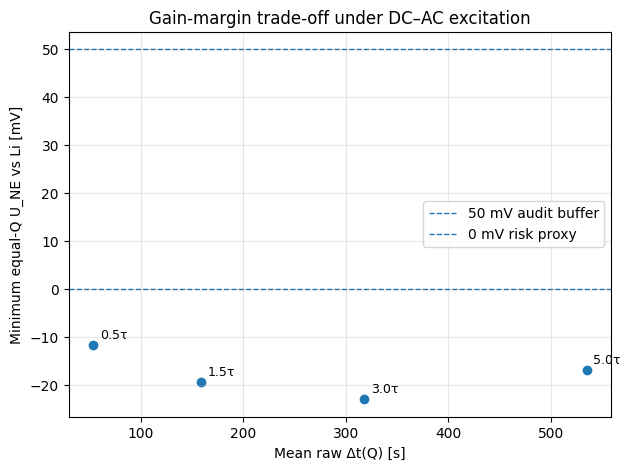

In [16]:
# Cell 14 — Plot timing gain versus plating margin（绘制时间收益与析锂余量关系）

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    ledger_df["delta_t_raw_mean_s"],
    ledger_df["U_NE_min_DCAC_min_mV"],
)

for _, row in ledger_df.iterrows():
    ax.annotate(
        f"{row['tau_factor_set']}τ",
        (row["delta_t_raw_mean_s"], row["U_NE_min_DCAC_min_mV"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )

ax.axhline(50, linestyle="--", linewidth=1, label="50 mV audit buffer")
ax.axhline(0, linestyle="--", linewidth=1, label="0 mV risk proxy")

ax.set_xlabel("Mean raw Δt(Q) [s]")
ax.set_ylabel("Minimum equal-Q U_NE vs Li [mV]")
ax.set_title("Gain-margin trade-off under DC–AC excitation")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Section B — Amplitude-reduction audit at fixed normalized frequency

The first Day31 smoke audit showed that all tested 0.3C + 0.7C DC–AC protocols crossed the 0 mV negative-electrode potential proxy in Chen2020 / DFN.

The next question is therefore not whether another frequency produces more timing gain, but whether reducing the AC amplitude can recover negative-electrode plating margin.

This section fixes the normalized frequency at 1.5τ_set, which was identified in Notebook30 as a balanced microstate-response region, and scans AC amplitude:

- 0.3C + 0.1C
- 0.3C + 0.2C
- 0.3C + 0.3C
- 0.3C + 0.4C
- 0.3C + 0.5C
- 0.3C + 0.7C

The goal is to identify the largest AC amplitude that preserves the hard 0 mV negative-electrode margin proxy while quantifying the remaining raw timing gain.

In [17]:
# Cell 15 — Define amplitude-reduction protocols at 1.5τ_set（定义1.5τ_set下的幅值降低审计工况）

AMP_TAU_FACTOR_SET = 1.5
AMP_F_HZ = f_from_tau_factor_set(AMP_TAU_FACTOR_SET)
AMP_PERIOD_S = 1.0 / AMP_F_HZ

AC_C_SCAN = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7]

amp_rows = []

# DC reference
amp_rows.append({
    "parameter_set": PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "condition": "Chen2020_DFN_amp_DC03",
    "protocol_type": "DC",
    "dc_c": DC_C,
    "ac_c": 0.0,
    "peak_c": DC_C,
    "tau_factor_set": np.nan,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_Hz": np.nan,
    "period_s": np.nan,
    "omega_tau_set": np.nan,
    "kappa": 0.0,
})

for ac_c in AC_C_SCAN:
    ac_label = str(ac_c).replace(".", "p")
    amp_rows.append({
        "parameter_set": PARAMETER_SET,
        "model_type": MODEL_TYPE,
        "condition": f"Chen2020_DFN_amp_DC03_AC{ac_label}_1p5tauSet",
        "protocol_type": "DCAC",
        "dc_c": DC_C,
        "ac_c": ac_c,
        "peak_c": DC_C + ac_c,
        "tau_factor_set": AMP_TAU_FACTOR_SET,
        "tau_ref_set_s": TAU_REF_SET_S,
        "f_Hz": AMP_F_HZ,
        "period_s": AMP_PERIOD_S,
        "omega_tau_set": 1.0 / AMP_TAU_FACTOR_SET,
        "kappa": ac_c / DC_C,
    })

amp_protocol_df = pd.DataFrame(amp_rows)

out = DATA_DIR / "day31_amplitude_protocol_table_1p5tau.csv"
amp_protocol_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(amp_protocol_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_protocol_table_1p5tau.csv


,parameter_set,model_type,condition,protocol_type,dc_c,ac_c,peak_c,tau_factor_set,tau_ref_set_s,f_Hz,period_s,omega_tau_set,kappa
0,Chen2020,DFN,Chen2020_DFN_amp_DC03,DC,0.3,0.0,0.3,NaN,36.316532,NaN,NaN,NaN,0.000000
1,Chen2020,DFN,Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet,DCAC,0.3,0.1,0.4,1.5,36.316532,0.002922,342.275253,0.666667,0.333333
2,Chen2020,DFN,Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet,DCAC,0.3,0.2,0.5,1.5,36.316532,0.002922,342.275253,0.666667,0.666667
3,Chen2020,DFN,Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet,DCAC,0.3,0.3,0.6,1.5,36.316532,0.002922,342.275253,0.666667,1.000000
4,Chen2020,DFN,Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet,DCAC,0.3,0.4,0.7,1.5,36.316532,0.002922,342.275253,0.666667,1.333333
5,Chen2020,DFN,Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet,DCAC,0.3,0.5,0.8,1.5,36.316532,0.002922,342.275253,0.666667,1.666667
6,Chen2020,DFN,Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet,DCAC,0.3,0.7,1.0,1.5,36.316532,0.002922,342.275253,0.666667,2.333333


In [18]:
# Cell 16 — Run amplitude-reduction simulations（运行幅值降低审计仿真）

amp_solutions = {}
amp_run_rows = []

for _, row in amp_protocol_df.iterrows():
    cond = row["condition"]
    
    # Reuse existing DC reference if available
    if row["protocol_type"] == "DC":
        print(f"[REUSE] {cond} <- Chen2020_DFN_DC03")
        amp_solutions[cond] = solutions["Chen2020_DFN_DC03"]
        ts = amp_solutions[cond]["ts"]
        amp_run_rows.append({
            "condition": cond,
            "status": "ok_reused",
            "termination": str(amp_solutions[cond]["sol"].termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "error": "",
        })
        continue
    
    print(f"\n[RUN] {cond}")
    
    try:
        sim, sol, ts, meta = run_simulation(row.to_dict())
        amp_solutions[cond] = {
            "sim": sim,
            "sol": sol,
            "ts": ts,
            "meta": meta,
            "protocol": row.to_dict(),
        }
        
        amp_run_rows.append({
            "condition": cond,
            "status": "ok",
            "termination": str(sol.termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "error": "",
        })
        print("[OK]", cond, "| termination:", sol.termination)
    
    except Exception as e:
        amp_run_rows.append({
            "condition": cond,
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

amp_run_summary_df = pd.DataFrame(amp_run_rows)

out = DATA_DIR / "day31_amplitude_run_summary_1p5tau.csv"
amp_run_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(amp_run_summary_df)

[REUSE] Chen2020_DFN_amp_DC03 <- Chen2020_DFN_DC03

[RUN] Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet
[OK] Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet
[OK] Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet
[OK] Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet
[OK] Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet
[OK] Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet
[OK] Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet | termination: event: Maximum voltage [V]
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_run_summary_1p5tau.csv


,condition,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,dc_c,ac_c,peak_c,tau_factor_set,error
0,Chen2020_DFN_amp_DC03,ok_reused,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000e+00,1.5,0.3,0.0,0.3,NaN,
1,Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet,ok,event: Maximum voltage [V],10653.155331,177.552589,4.441013,4.2,1.000000e+00,2.0,0.3,0.1,0.4,1.5,
2,Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet,ok,event: Maximum voltage [V],10330.346615,172.172444,4.313115,4.2,5.000000e-01,2.5,0.3,0.2,0.5,1.5,
3,Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet,ok,event: Maximum voltage [V],9661.819662,161.030328,4.045353,4.2,9.853115e-08,3.0,0.3,0.3,0.6,1.5,
4,Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet,ok,event: Maximum voltage [V],9312.498817,155.208314,3.902494,4.2,-5.000000e-01,3.5,0.3,0.4,0.7,1.5,
5,Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet,ok,event: Maximum voltage [V],8975.428074,149.590468,3.771150,4.2,-9.999999e-01,4.0,0.3,0.5,0.8,1.5,
6,Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet,ok,event: Maximum voltage [V],8627.912611,143.798544,3.633942,4.2,-2.000000e+00,5.0,0.3,0.7,1.0,1.5,


In [19]:
# Cell 17 — Extract plating-margin timeseries for amplitude scan（提取幅值扫描析锂余量时间序列）

def extract_margin_timeseries_from_solution(obj):
    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()
    
    raw_surface = sol[NE_SURFACE_KEY](t_s)
    raw_surface_arr = np.asarray(raw_surface)
    
    ts["U_NE_vs_Li_min_V"] = reduce_variable_to_timeseries(raw_surface_arr, t_s, reducer="min")
    ts["U_NE_vs_Li_mean_V"] = reduce_variable_to_timeseries(raw_surface_arr, t_s, reducer="mean")
    
    raw_sep = sol[NE_SEPARATOR_KEY](t_s)
    ts["U_NE_vs_Li_separator_V"] = reduce_variable_to_timeseries(raw_sep, t_s, reducer="mean")
    
    raw_xavg = sol[NE_XAVG_KEY](t_s)
    ts["U_NE_vs_Li_xavg_V"] = reduce_variable_to_timeseries(raw_xavg, t_s, reducer="mean")
    
    ts["U_NE_margin_min_mV"] = ts["U_NE_vs_Li_min_V"] * 1000.0
    ts["U_NE_margin_separator_mV"] = ts["U_NE_vs_Li_separator_V"] * 1000.0
    ts["margin_class_inst"] = ts["U_NE_vs_Li_min_V"].apply(classify_margin)
    
    return ts

amp_margin_ts_map = {}
amp_margin_audit_rows = []

for cond, obj in amp_solutions.items():
    print("[EXTRACT]", cond)
    ts = extract_margin_timeseries_from_solution(obj)
    amp_margin_ts_map[cond] = ts
    
    amp_margin_audit_rows.append({
        "condition": cond,
        "status": "ok",
        "n_time": len(ts),
        "min_U_NE_mV": float(ts["U_NE_margin_min_mV"].min()),
        "fraction_time_below_50mV": float((ts["U_NE_vs_Li_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_vs_Li_min_V"] <= 0.0).mean()),
    })

amp_margin_audit_df = pd.DataFrame(amp_margin_audit_rows)

out = DATA_DIR / "day31_amplitude_margin_extraction_audit_1p5tau.csv"
amp_margin_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(amp_margin_audit_df)

[EXTRACT] Chen2020_DFN_amp_DC03
[EXTRACT] Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet
[EXTRACT] Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet
[EXTRACT] Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet
[EXTRACT] Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet
[EXTRACT] Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet
[EXTRACT] Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_margin_extraction_audit_1p5tau.csv


,condition,status,n_time,min_U_NE_mV,fraction_time_below_50mV,fraction_time_below_0mV
0,Chen2020_DFN_amp_DC03,ok,12159,37.280562,0.219837,0.000000
1,Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet,ok,13177,25.760879,0.155802,0.000000
2,Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet,ok,14264,15.144144,0.142246,0.000000
3,Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet,ok,14209,6.661005,0.128721,0.000000
4,Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet,ok,14634,-1.327813,0.156143,0.002733
5,Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet,ok,14563,-9.386875,0.186843,0.018540
6,Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet,ok,14885,-25.298691,0.222304,0.039973


In [20]:
# Cell 18 — Protocol-level amplitude margin summary（协议级幅值-析锂余量摘要）

amp_protocol_summary_rows = []

for _, pr in amp_protocol_df.iterrows():
    cond = pr["condition"]
    ts = amp_margin_ts_map[cond]
    
    idx_min = int(ts["U_NE_vs_Li_min_V"].idxmin())
    row_min = ts.loc[idx_min]
    
    min_u = float(row_min["U_NE_vs_Li_min_V"])
    
    amp_protocol_summary_rows.append({
        "condition": cond,
        "protocol_type": pr["protocol_type"],
        "dc_c": pr["dc_c"],
        "ac_c": pr["ac_c"],
        "peak_c": pr["peak_c"],
        "tau_factor_set": pr["tau_factor_set"],
        "t_end_min": float(ts["t_s"].iloc[-1] / 60),
        "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
        "min_U_NE_vs_Li_mV": min_u * 1000.0,
        "min_U_NE_separator_mV": float(ts["U_NE_vs_Li_separator_V"].min() * 1000.0),
        "min_U_NE_xavg_mV": float(ts["U_NE_vs_Li_xavg_V"].min() * 1000.0),
        "t_at_min_U_NE_s": float(row_min["t_s"]),
        "Q_at_min_U_NE_Ah": float(row_min["Q_net_Ah"]),
        "I_charge_at_min_U_NE_A": float(row_min["I_charge_A"]),
        "fraction_time_below_50mV": float((ts["U_NE_vs_Li_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_vs_Li_min_V"] <= 0.0).mean()),
        "margin_class": classify_margin(min_u),
    })

amp_protocol_margin_summary_df = pd.DataFrame(amp_protocol_summary_rows)

out = DATA_DIR / "day31_amplitude_protocol_margin_summary_1p5tau.csv"
amp_protocol_margin_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(amp_protocol_margin_summary_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_protocol_margin_summary_1p5tau.csv


,condition,protocol_type,dc_c,ac_c,peak_c,tau_factor_set,t_end_min,Q_end_Ah,min_U_NE_vs_Li_mV,min_U_NE_separator_mV,min_U_NE_xavg_mV,t_at_min_U_NE_s,Q_at_min_U_NE_Ah,I_charge_at_min_U_NE_A,fraction_time_below_50mV,fraction_time_below_0mV,margin_class
0,Chen2020_DFN_amp_DC03,DC,0.3,0.0,0.3,NaN,179.715160,4.492879,37.280562,37.917452,46.709659,10782.909607,4.492879,1.500000,0.219837,0.000000,near_boundary
1,Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet,DCAC,0.3,0.1,0.4,1.5,177.552589,4.441013,25.760879,26.584354,37.751084,10360.472094,4.325348,1.996284,0.155802,0.000000,near_boundary
2,Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet,DCAC,0.3,0.2,0.5,1.5,172.172444,4.313115,15.144144,16.154976,29.679258,10019.030571,4.191793,2.490589,0.142246,0.000000,near_boundary
3,Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet,DCAC,0.3,0.3,0.6,1.5,161.030328,4.045353,6.661005,7.826375,23.236443,9661.819662,4.045353,2.985971,0.128721,0.000000,near_boundary
4,Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet,DCAC,0.3,0.4,0.7,1.5,155.208314,3.902494,-1.327813,0.053304,18.103426,8992.198440,3.781135,3.481210,0.156143,0.002733,risk_flag
5,Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet,DCAC,0.3,0.5,0.8,1.5,149.590468,3.771150,-9.386875,-7.823621,11.946417,8648.750329,3.645825,3.983299,0.186843,0.018540,risk_flag
6,Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet,DCAC,0.3,0.7,1.0,1.5,143.798544,3.633942,-25.298691,-23.359654,1.830032,8309.072266,3.523668,4.953419,0.222304,0.039973,risk_flag


In [21]:
# Cell 19 — Equal-Q amplitude margin summary（等Q幅值-析锂余量摘要）

DC_AMP_COND = "Chen2020_DFN_amp_DC03"

def first_passage_time(t_s, q_Ah, q_target_Ah):
    t_s = np.asarray(t_s, dtype=float)
    q_Ah = np.asarray(q_Ah, dtype=float)
    hit = np.where(q_Ah >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan
    i = int(hit[0])
    if i == 0:
        return float(t_s[0])
    q0, q1 = q_Ah[i - 1], q_Ah[i]
    t0, t1 = t_s[i - 1], t_s[i]
    if q1 == q0:
        return float(t1)
    frac = (q_target_Ah - q0) / (q1 - q0)
    return float(t0 + frac * (t1 - t0))

def interp_at_time(t_s, y, t_target):
    if np.isnan(t_target):
        return np.nan
    return float(np.interp(t_target, t_s, y))

q_end_by_cond = {
    cond: float(ts["Q_net_Ah"].max())
    for cond, ts in amp_margin_ts_map.items()
}
q_hi_raw = min(q_end_by_cond.values())
q_grid_amp = np.linspace(0.2, 0.95 * q_hi_raw, 100)

print("[OK] amplitude Q_end_by_cond:")
for k, v in q_end_by_cond.items():
    print(f"  {k}: {v:.6f} Ah")
print(f"[OK] Q grid: {q_grid_amp[0]:.6f} → {q_grid_amp[-1]:.6f} Ah")

eq_rows = []

for _, pr in amp_protocol_df.iterrows():
    cond = pr["condition"]
    ts = amp_margin_ts_map[cond]
    t_arr = ts["t_s"].to_numpy()
    q_arr = ts["Q_net_Ah"].to_numpy()
    
    for q in q_grid_amp:
        t_q = first_passage_time(t_arr, q_arr, q)
        rec = {
            "condition": cond,
            "protocol_type": pr["protocol_type"],
            "dc_c": pr["dc_c"],
            "ac_c": pr["ac_c"],
            "peak_c": pr["peak_c"],
            "tau_factor_set": pr["tau_factor_set"],
            "Q_Ah": float(q),
            "t_q_s": t_q,
            "U_NE_min_mV": interp_at_time(t_arr, ts["U_NE_vs_Li_min_V"].to_numpy(), t_q) * 1000.0,
            "I_charge_A": interp_at_time(t_arr, ts["I_charge_A"].to_numpy(), t_q),
            "V_terminal_V": interp_at_time(t_arr, ts["V_terminal_V"].to_numpy(), t_q),
        }
        rec["margin_class_at_Q"] = classify_margin(rec["U_NE_min_mV"] / 1000.0)
        eq_rows.append(rec)

amp_equalq_margin_df = pd.DataFrame(eq_rows)

out = DATA_DIR / "day31_amplitude_equalQ_margin_curves_1p5tau.csv"
amp_equalq_margin_df.to_csv(out, index=False)

print("[OK] saved:", out)

dc_eq = amp_equalq_margin_df[amp_equalq_margin_df["condition"] == DC_AMP_COND].set_index("Q_Ah")

delta_rows = []

for cond, g in amp_equalq_margin_df.groupby("condition"):
    if cond == DC_AMP_COND:
        continue
    
    ac_eq = g.set_index("Q_Ah")
    
    for q in q_grid_amp:
        q = float(q)
        dc_row = dc_eq.loc[q]
        ac_row = ac_eq.loc[q]
        
        delta_rows.append({
            "condition": cond,
            "dc_c": ac_row["dc_c"],
            "ac_c": ac_row["ac_c"],
            "peak_c": ac_row["peak_c"],
            "tau_factor_set": ac_row["tau_factor_set"],
            "Q_Ah": q,
            "delta_t_raw_s": float(dc_row["t_q_s"] - ac_row["t_q_s"]),
            "U_NE_min_DCAC_mV": float(ac_row["U_NE_min_mV"]),
            "U_NE_min_DC_mV": float(dc_row["U_NE_min_mV"]),
            "delta_U_NE_min_mV": float(ac_row["U_NE_min_mV"] - dc_row["U_NE_min_mV"]),
            "margin_class_at_Q": ac_row["margin_class_at_Q"],
        })

amp_delta_margin_df = pd.DataFrame(delta_rows)

amp_equalq_summary_df = (
    amp_delta_margin_df
    .groupby(["condition", "dc_c", "ac_c", "peak_c", "tau_factor_set"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        U_NE_min_DCAC_min_mV=("U_NE_min_DCAC_mV", "min"),
        U_NE_min_DCAC_mean_mV=("U_NE_min_DCAC_mV", "mean"),
        delta_U_NE_min_mean_mV=("delta_U_NE_min_mV", "mean"),
        fraction_Q_below_50mV=("U_NE_min_DCAC_mV", lambda x: np.mean(x <= 50.0)),
        fraction_Q_below_0mV=("U_NE_min_DCAC_mV", lambda x: np.mean(x <= 0.0)),
    )
)

amp_equalq_summary_df["equalQ_margin_class"] = amp_equalq_summary_df["U_NE_min_DCAC_min_mV"].apply(
    lambda x: classify_margin(x / 1000.0)
)

out = DATA_DIR / "day31_amplitude_equalQ_margin_summary_1p5tau.csv"
amp_equalq_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(amp_equalq_summary_df)

[OK] amplitude Q_end_by_cond:
  Chen2020_DFN_amp_DC03: 4.492879 Ah
  Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet: 4.441013 Ah
  Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet: 4.313115 Ah
  Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet: 4.045353 Ah
  Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet: 3.902494 Ah
  Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet: 3.771150 Ah
  Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet: 3.633942 Ah
[OK] Q grid: 0.200000 → 3.452245 Ah
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_equalQ_margin_curves_1p5tau.csv
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_equalQ_margin_summary_1p5tau.csv


,condition,dc_c,ac_c,peak_c,tau_factor_set,delta_t_raw_mean_s,U_NE_min_DCAC_min_mV,U_NE_min_DCAC_mean_mV,delta_U_NE_min_mean_mV,fraction_Q_below_50mV,fraction_Q_below_0mV,equalQ_margin_class
0,Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet,0.3,0.1,0.4,1.5,18.155482,38.117164,115.318979,-2.140963,0.04,0.00,near_boundary
1,Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet,0.3,0.2,0.5,1.5,36.370609,29.381962,108.998556,-8.461385,0.07,0.00,near_boundary
2,Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet,0.3,0.3,0.6,1.5,53.953401,16.813850,98.392526,-19.067415,0.14,0.00,near_boundary
3,Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet,0.3,0.4,0.7,1.5,75.416853,5.680958,85.534219,-31.925723,0.27,0.00,near_boundary
4,Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet,0.3,0.5,0.8,1.5,102.862474,-3.577476,73.839536,-43.620406,0.42,0.02,risk_flag
5,Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet,0.3,0.7,1.0,1.5,158.670924,-22.184358,52.262914,-65.197027,0.61,0.11,risk_flag


In [22]:
# Cell 20 — Amplitude admissibility ledger（幅值准入账本）

amp_ledger_df = amp_equalq_summary_df.merge(
    amp_protocol_margin_summary_df[
        [
            "condition",
            "min_U_NE_vs_Li_mV",
            "fraction_time_below_50mV",
            "fraction_time_below_0mV",
            "margin_class",
        ]
    ],
    on="condition",
    how="left",
)

def classify_timing_gain(delta_t_s):
    if pd.isna(delta_t_s):
        return "unresolved"
    if delta_t_s > 60:
        return "clear_raw_gain"
    if delta_t_s > 10:
        return "weak_raw_gain"
    if delta_t_s >= -10:
        return "near_zero"
    return "penalty"

def classify_amplitude_admissibility(row):
    if row["margin_class"] == "risk_flag" or row["equalQ_margin_class"] == "risk_flag":
        return "not_admissible_hard_margin"
    if row["margin_class"] == "near_boundary" or row["equalQ_margin_class"] == "near_boundary":
        return "admissible_but_near_boundary"
    if row["margin_class"] == "safe_margin" and row["equalQ_margin_class"] == "safe_margin":
        return "admissible_with_safe_margin"
    return "unresolved"

amp_ledger_df["timing_gain_class"] = amp_ledger_df["delta_t_raw_mean_s"].apply(classify_timing_gain)
amp_ledger_df["amplitude_admissibility"] = amp_ledger_df.apply(classify_amplitude_admissibility, axis=1)

out = DATA_DIR / "day31_amplitude_admissibility_ledger_1p5tau.csv"
amp_ledger_df.to_csv(out, index=False)

print("[OK] saved:", out)

cols = [
    "condition",
    "ac_c",
    "peak_c",
    "delta_t_raw_mean_s",
    "U_NE_min_DCAC_min_mV",
    "U_NE_min_DCAC_mean_mV",
    "fraction_Q_below_50mV",
    "fraction_Q_below_0mV",
    "min_U_NE_vs_Li_mV",
    "fraction_time_below_50mV",
    "fraction_time_below_0mV",
    "timing_gain_class",
    "margin_class",
    "equalQ_margin_class",
    "amplitude_admissibility",
]

display(amp_ledger_df[cols])

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_admissibility_ledger_1p5tau.csv


,condition,ac_c,peak_c,delta_t_raw_mean_s,U_NE_min_DCAC_min_mV,U_NE_min_DCAC_mean_mV,fraction_Q_below_50mV,fraction_Q_below_0mV,min_U_NE_vs_Li_mV,fraction_time_below_50mV,fraction_time_below_0mV,timing_gain_class,margin_class,equalQ_margin_class,amplitude_admissibility
0,Chen2020_DFN_amp_DC03_AC0p1_1p5tauSet,0.1,0.4,18.155482,38.117164,115.318979,0.04,0.00,25.760879,0.155802,0.000000,weak_raw_gain,near_boundary,near_boundary,admissible_but_near_boundary
1,Chen2020_DFN_amp_DC03_AC0p2_1p5tauSet,0.2,0.5,36.370609,29.381962,108.998556,0.07,0.00,15.144144,0.142246,0.000000,weak_raw_gain,near_boundary,near_boundary,admissible_but_near_boundary
2,Chen2020_DFN_amp_DC03_AC0p3_1p5tauSet,0.3,0.6,53.953401,16.813850,98.392526,0.14,0.00,6.661005,0.128721,0.000000,weak_raw_gain,near_boundary,near_boundary,admissible_but_near_boundary
3,Chen2020_DFN_amp_DC03_AC0p4_1p5tauSet,0.4,0.7,75.416853,5.680958,85.534219,0.27,0.00,-1.327813,0.156143,0.002733,clear_raw_gain,risk_flag,near_boundary,not_admissible_hard_margin
4,Chen2020_DFN_amp_DC03_AC0p5_1p5tauSet,0.5,0.8,102.862474,-3.577476,73.839536,0.42,0.02,-9.386875,0.186843,0.018540,clear_raw_gain,risk_flag,risk_flag,not_admissible_hard_margin
5,Chen2020_DFN_amp_DC03_AC0p7_1p5tauSet,0.7,1.0,158.670924,-22.184358,52.262914,0.61,0.11,-25.298691,0.222304,0.039973,clear_raw_gain,risk_flag,risk_flag,not_admissible_hard_margin


In [23]:
# Cell 21 — Estimate AC-amplitude hard-margin boundary（估计AC幅值hard-margin边界）

def estimate_zero_crossing(x, y):
    """
    Estimate x where y crosses zero by linear interpolation.
    Assumes x sorted ascending.
    Returns NaN if no sign crossing.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    
    for i in range(1, len(x)):
        if y[i - 1] == 0:
            return float(x[i - 1])
        if y[i - 1] > 0 and y[i] <= 0:
            x0, x1 = x[i - 1], x[i]
            y0, y1 = y[i - 1], y[i]
            return float(x0 + (0 - y0) * (x1 - x0) / (y1 - y0))
    return np.nan

# Protocol-level boundary
prot_ac = amp_protocol_margin_summary_df.loc[
    amp_protocol_margin_summary_df["protocol_type"] == "DCAC", "ac_c"
].to_numpy()

prot_min_u = amp_protocol_margin_summary_df.loc[
    amp_protocol_margin_summary_df["protocol_type"] == "DCAC", "min_U_NE_vs_Li_mV"
].to_numpy()

protocol_zero_cross_ac = estimate_zero_crossing(prot_ac, prot_min_u)

# Equal-Q boundary
eq_ac = amp_equalq_summary_df["ac_c"].to_numpy()
eq_min_u = amp_equalq_summary_df["U_NE_min_DCAC_min_mV"].to_numpy()

equalq_zero_cross_ac = estimate_zero_crossing(eq_ac, eq_min_u)

boundary_summary_df = pd.DataFrame([
    {
        "boundary_type": "full_protocol_min_U_NE",
        "estimated_AC_C_at_0mV": protocol_zero_cross_ac,
        "estimated_peak_C_at_0mV": DC_C + protocol_zero_cross_ac,
        "interpretation": "conservative hard-margin admissibility boundary",
    },
    {
        "boundary_type": "common_equalQ_min_U_NE",
        "estimated_AC_C_at_0mV": equalq_zero_cross_ac,
        "estimated_peak_C_at_0mV": DC_C + equalq_zero_cross_ac,
        "interpretation": "shared-Q hard-margin boundary",
    },
])

out = DATA_DIR / "day31_amplitude_hard_margin_boundary_estimate_1p5tau.csv"
boundary_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(boundary_summary_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_hard_margin_boundary_estimate_1p5tau.csv


,boundary_type,estimated_AC_C_at_0mV,estimated_peak_C_at_0mV,interpretation
0,full_protocol_min_U_NE,0.383379,0.683379,conservative hard-margin admissibility boundary
1,common_equalQ_min_U_NE,0.461360,0.761360,shared-Q hard-margin boundary


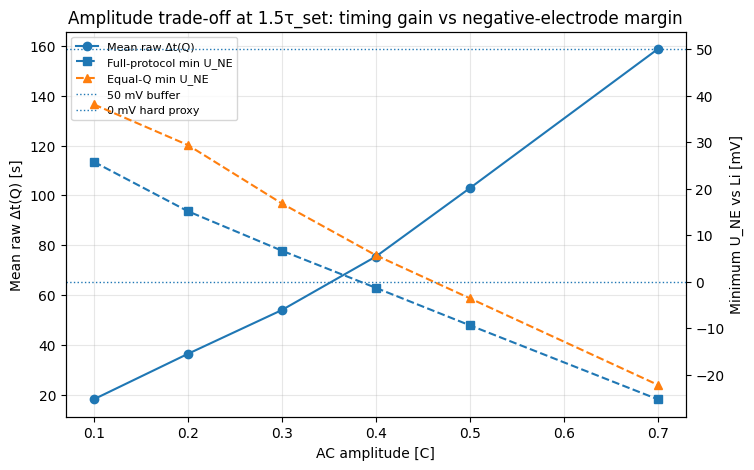

In [24]:
# Cell 22 — Plot amplitude-gain-margin trade-off（绘制幅值-时间收益-析锂余量权衡）

plot_df = amp_ledger_df.sort_values("ac_c").copy()

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(
    plot_df["ac_c"],
    plot_df["delta_t_raw_mean_s"],
    marker="o",
    label="Mean raw Δt(Q)",
)
ax1.set_xlabel("AC amplitude [C]")
ax1.set_ylabel("Mean raw Δt(Q) [s]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    plot_df["ac_c"],
    plot_df["min_U_NE_vs_Li_mV"],
    marker="s",
    linestyle="--",
    label="Full-protocol min U_NE",
)
ax2.plot(
    plot_df["ac_c"],
    plot_df["U_NE_min_DCAC_min_mV"],
    marker="^",
    linestyle="--",
    label="Equal-Q min U_NE",
)

ax2.axhline(50, linestyle=":", linewidth=1, label="50 mV buffer")
ax2.axhline(0, linestyle=":", linewidth=1, label="0 mV hard proxy")
ax2.set_ylabel("Minimum U_NE vs Li [mV]")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)

ax1.set_title("Amplitude trade-off at 1.5τ_set: timing gain vs negative-electrode margin")
plt.show()

In [25]:
# Cell 23 — Define fine amplitude-boundary scan at 1.5τ_set（定义1.5τ_set下精细幅值边界扫描）

FINE_AMP_TAU_FACTOR_SET = 1.5
FINE_AMP_F_HZ = f_from_tau_factor_set(FINE_AMP_TAU_FACTOR_SET)
FINE_AMP_PERIOD_S = 1.0 / FINE_AMP_F_HZ

FINE_AC_C_SCAN = [0.30, 0.32, 0.34, 0.36, 0.38, 0.40]

fine_amp_rows = []

# DC reference
fine_amp_rows.append({
    "parameter_set": PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "condition": "Chen2020_DFN_fineAmp_DC03",
    "protocol_type": "DC",
    "dc_c": DC_C,
    "ac_c": 0.0,
    "peak_c": DC_C,
    "tau_factor_set": np.nan,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_Hz": np.nan,
    "period_s": np.nan,
    "omega_tau_set": np.nan,
    "kappa": 0.0,
})

for ac_c in FINE_AC_C_SCAN:
    ac_label = str(ac_c).replace(".", "p")
    fine_amp_rows.append({
        "parameter_set": PARAMETER_SET,
        "model_type": MODEL_TYPE,
        "condition": f"Chen2020_DFN_fineAmp_DC03_AC{ac_label}_1p5tauSet",
        "protocol_type": "DCAC",
        "dc_c": DC_C,
        "ac_c": ac_c,
        "peak_c": DC_C + ac_c,
        "tau_factor_set": FINE_AMP_TAU_FACTOR_SET,
        "tau_ref_set_s": TAU_REF_SET_S,
        "f_Hz": FINE_AMP_F_HZ,
        "period_s": FINE_AMP_PERIOD_S,
        "omega_tau_set": 1.0 / FINE_AMP_TAU_FACTOR_SET,
        "kappa": ac_c / DC_C,
    })

fine_amp_protocol_df = pd.DataFrame(fine_amp_rows)

out = DATA_DIR / "day31_fine_amplitude_protocol_table_1p5tau.csv"
fine_amp_protocol_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(fine_amp_protocol_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_fine_amplitude_protocol_table_1p5tau.csv


,parameter_set,model_type,condition,protocol_type,dc_c,ac_c,peak_c,tau_factor_set,tau_ref_set_s,f_Hz,period_s,omega_tau_set,kappa
0,Chen2020,DFN,Chen2020_DFN_fineAmp_DC03,DC,0.3,0.00,0.30,NaN,36.316532,NaN,NaN,NaN,0.000000
1,Chen2020,DFN,Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet,DCAC,0.3,0.30,0.60,1.5,36.316532,0.002922,342.275253,0.666667,1.000000
2,Chen2020,DFN,Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet,DCAC,0.3,0.32,0.62,1.5,36.316532,0.002922,342.275253,0.666667,1.066667
3,Chen2020,DFN,Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet,DCAC,0.3,0.34,0.64,1.5,36.316532,0.002922,342.275253,0.666667,1.133333
4,Chen2020,DFN,Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet,DCAC,0.3,0.36,0.66,1.5,36.316532,0.002922,342.275253,0.666667,1.200000
5,Chen2020,DFN,Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet,DCAC,0.3,0.38,0.68,1.5,36.316532,0.002922,342.275253,0.666667,1.266667
6,Chen2020,DFN,Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet,DCAC,0.3,0.40,0.70,1.5,36.316532,0.002922,342.275253,0.666667,1.333333


In [26]:
# Cell 24 — Run fine amplitude-boundary simulations（运行精细幅值边界仿真）

fine_amp_solutions = {}
fine_amp_run_rows = []

for _, row in fine_amp_protocol_df.iterrows():
    cond = row["condition"]
    
    # Reuse DC reference
    if row["protocol_type"] == "DC":
        print(f"[REUSE] {cond} <- Chen2020_DFN_DC03")
        fine_amp_solutions[cond] = solutions["Chen2020_DFN_DC03"]
        ts = fine_amp_solutions[cond]["ts"]
        fine_amp_run_rows.append({
            "condition": cond,
            "status": "ok_reused",
            "termination": str(fine_amp_solutions[cond]["sol"].termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "error": "",
        })
        continue
    
    print(f"\n[RUN] {cond}")
    
    try:
        sim, sol, ts, meta = run_simulation(row.to_dict())
        fine_amp_solutions[cond] = {
            "sim": sim,
            "sol": sol,
            "ts": ts,
            "meta": meta,
            "protocol": row.to_dict(),
        }
        
        fine_amp_run_rows.append({
            "condition": cond,
            "status": "ok",
            "termination": str(sol.termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "error": "",
        })
        print("[OK]", cond, "| termination:", sol.termination)
    
    except Exception as e:
        fine_amp_run_rows.append({
            "condition": cond,
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

fine_amp_run_summary_df = pd.DataFrame(fine_amp_run_rows)

out = DATA_DIR / "day31_fine_amplitude_run_summary_1p5tau.csv"
fine_amp_run_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(fine_amp_run_summary_df)

[REUSE] Chen2020_DFN_fineAmp_DC03 <- Chen2020_DFN_DC03

[RUN] Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet
[OK] Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet
[OK] Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet
[OK] Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet
[OK] Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet
[OK] Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet
[OK] Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet | termination: event: Maximum voltage [V]
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_fine_amplitude_run_summary_1p5tau.csv


,condition,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,dc_c,ac_c,peak_c,tau_factor_set,error
0,Chen2020_DFN_fineAmp_DC03,ok_reused,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000e+00,1.5,0.3,0.00,0.30,NaN,
1,Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet,ok,event: Maximum voltage [V],9661.819662,161.030328,4.045353,4.2,9.853115e-08,3.0,0.3,0.30,0.60,1.5,
2,Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet,ok,event: Maximum voltage [V],9653.610227,160.893504,4.039675,4.2,-9.999999e-02,3.1,0.3,0.32,0.62,1.5,
3,Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet,ok,event: Maximum voltage [V],9648.061829,160.801030,4.035974,4.2,-2.000000e-01,3.2,0.3,0.34,0.64,1.5,
4,Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet,ok,event: Maximum voltage [V],9325.524778,155.425413,3.912123,4.2,-3.000000e-01,3.3,0.3,0.36,0.66,1.5,
5,Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet,ok,event: Maximum voltage [V],9317.813665,155.296894,3.906333,4.2,-4.000000e-01,3.4,0.3,0.38,0.68,1.5,
6,Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet,ok,event: Maximum voltage [V],9312.498817,155.208314,3.902494,4.2,-5.000000e-01,3.5,0.3,0.40,0.70,1.5,


In [27]:
# Cell 25 — Extract fine amplitude plating-margin timeseries（提取精细幅值扫描析锂余量时间序列）

fine_amp_margin_ts_map = {}
fine_amp_margin_audit_rows = []

for cond, obj in fine_amp_solutions.items():
    print("[EXTRACT]", cond)
    ts = extract_margin_timeseries_from_solution(obj)
    fine_amp_margin_ts_map[cond] = ts
    
    fine_amp_margin_audit_rows.append({
        "condition": cond,
        "status": "ok",
        "n_time": len(ts),
        "min_U_NE_mV": float(ts["U_NE_margin_min_mV"].min()),
        "fraction_time_below_50mV": float((ts["U_NE_vs_Li_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_vs_Li_min_V"] <= 0.0).mean()),
    })

fine_amp_margin_audit_df = pd.DataFrame(fine_amp_margin_audit_rows)

out = DATA_DIR / "day31_fine_amplitude_margin_extraction_audit_1p5tau.csv"
fine_amp_margin_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(fine_amp_margin_audit_df)

[EXTRACT] Chen2020_DFN_fineAmp_DC03
[EXTRACT] Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet
[EXTRACT] Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet
[EXTRACT] Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet
[EXTRACT] Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet
[EXTRACT] Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet
[EXTRACT] Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_fine_amplitude_margin_extraction_audit_1p5tau.csv


,condition,status,n_time,min_U_NE_mV,fraction_time_below_50mV,fraction_time_below_0mV
0,Chen2020_DFN_fineAmp_DC03,ok,12159,37.280562,0.219837,0.000000
1,Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet,ok,14209,6.661005,0.128721,0.000000
2,Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet,ok,14364,5.312510,0.131300,0.000000
3,Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet,ok,14622,3.145861,0.134318,0.000000
4,Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet,ok,14356,1.432702,0.130886,0.000000
5,Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet,ok,14511,0.584036,0.145062,0.000000
6,Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet,ok,14634,-1.327813,0.156143,0.002733


In [28]:
# Cell 26 — Fine amplitude protocol-level margin summary（精细幅值协议级析锂余量摘要）

fine_amp_protocol_summary_rows = []

for _, pr in fine_amp_protocol_df.iterrows():
    cond = pr["condition"]
    ts = fine_amp_margin_ts_map[cond]
    
    idx_min = int(ts["U_NE_vs_Li_min_V"].idxmin())
    row_min = ts.loc[idx_min]
    
    min_u = float(row_min["U_NE_vs_Li_min_V"])
    
    fine_amp_protocol_summary_rows.append({
        "condition": cond,
        "protocol_type": pr["protocol_type"],
        "dc_c": pr["dc_c"],
        "ac_c": pr["ac_c"],
        "peak_c": pr["peak_c"],
        "tau_factor_set": pr["tau_factor_set"],
        "t_end_min": float(ts["t_s"].iloc[-1] / 60),
        "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
        "min_U_NE_vs_Li_mV": min_u * 1000.0,
        "min_U_NE_separator_mV": float(ts["U_NE_vs_Li_separator_V"].min() * 1000.0),
        "min_U_NE_xavg_mV": float(ts["U_NE_vs_Li_xavg_V"].min() * 1000.0),
        "t_at_min_U_NE_s": float(row_min["t_s"]),
        "Q_at_min_U_NE_Ah": float(row_min["Q_net_Ah"]),
        "I_charge_at_min_U_NE_A": float(row_min["I_charge_A"]),
        "fraction_time_below_50mV": float((ts["U_NE_vs_Li_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_vs_Li_min_V"] <= 0.0).mean()),
        "margin_class": classify_margin(min_u),
    })

fine_amp_protocol_margin_summary_df = pd.DataFrame(fine_amp_protocol_summary_rows)

out = DATA_DIR / "day31_fine_amplitude_protocol_margin_summary_1p5tau.csv"
fine_amp_protocol_margin_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(fine_amp_protocol_margin_summary_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_fine_amplitude_protocol_margin_summary_1p5tau.csv


,condition,protocol_type,dc_c,ac_c,peak_c,tau_factor_set,t_end_min,Q_end_Ah,min_U_NE_vs_Li_mV,min_U_NE_separator_mV,min_U_NE_xavg_mV,t_at_min_U_NE_s,Q_at_min_U_NE_Ah,I_charge_at_min_U_NE_A,fraction_time_below_50mV,fraction_time_below_0mV,margin_class
0,Chen2020_DFN_fineAmp_DC03,DC,0.3,0.00,0.30,NaN,179.715160,4.492879,37.280562,37.917452,46.709659,10782.909607,4.492879,1.500000,0.219837,0.000000,near_boundary
1,Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet,DCAC,0.3,0.30,0.60,1.5,161.030328,4.045353,6.661005,7.826375,23.236443,9661.819662,4.045353,2.985971,0.128721,0.000000,near_boundary
2,Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet,DCAC,0.3,0.32,0.62,1.5,160.893504,4.039675,5.312510,6.546031,22.701881,9333.494679,3.916040,3.088644,0.131300,0.000000,near_boundary
3,Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet,DCAC,0.3,0.34,0.64,1.5,160.801030,4.035974,3.145861,4.417205,21.149280,9333.885494,3.918076,3.186441,0.134318,0.000000,near_boundary
4,Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet,DCAC,0.3,0.36,0.66,1.5,155.425413,3.912123,1.432702,2.723809,19.690364,9325.524778,3.912123,3.299339,0.130886,0.000000,near_boundary
5,Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet,DCAC,0.3,0.38,0.68,1.5,155.296894,3.906333,0.584036,1.879212,18.853795,9317.813665,3.906333,3.373045,0.145062,0.000000,near_boundary
6,Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet,DCAC,0.3,0.40,0.70,1.5,155.208314,3.902494,-1.327813,0.053304,18.103426,8992.198440,3.781135,3.481210,0.156143,0.002733,risk_flag


In [29]:
# Cell 27 — Fine amplitude equal-Q margin and boundary estimate（精细幅值等Q余量与边界估计）

DC_FINE_AMP_COND = "Chen2020_DFN_fineAmp_DC03"

q_end_by_cond = {
    cond: float(ts["Q_net_Ah"].max())
    for cond, ts in fine_amp_margin_ts_map.items()
}
q_hi_raw = min(q_end_by_cond.values())
q_grid_fine_amp = np.linspace(0.2, 0.95 * q_hi_raw, 100)

print("[OK] fine amplitude Q_end_by_cond:")
for k, v in q_end_by_cond.items():
    print(f"  {k}: {v:.6f} Ah")
print(f"[OK] Q grid: {q_grid_fine_amp[0]:.6f} → {q_grid_fine_amp[-1]:.6f} Ah")

fine_eq_rows = []

for _, pr in fine_amp_protocol_df.iterrows():
    cond = pr["condition"]
    ts = fine_amp_margin_ts_map[cond]
    t_arr = ts["t_s"].to_numpy()
    q_arr = ts["Q_net_Ah"].to_numpy()
    
    for q in q_grid_fine_amp:
        t_q = first_passage_time(t_arr, q_arr, q)
        rec = {
            "condition": cond,
            "protocol_type": pr["protocol_type"],
            "dc_c": pr["dc_c"],
            "ac_c": pr["ac_c"],
            "peak_c": pr["peak_c"],
            "tau_factor_set": pr["tau_factor_set"],
            "Q_Ah": float(q),
            "t_q_s": t_q,
            "U_NE_min_mV": interp_at_time(t_arr, ts["U_NE_vs_Li_min_V"].to_numpy(), t_q) * 1000.0,
            "I_charge_A": interp_at_time(t_arr, ts["I_charge_A"].to_numpy(), t_q),
            "V_terminal_V": interp_at_time(t_arr, ts["V_terminal_V"].to_numpy(), t_q),
        }
        rec["margin_class_at_Q"] = classify_margin(rec["U_NE_min_mV"] / 1000.0)
        fine_eq_rows.append(rec)

fine_amp_equalq_margin_df = pd.DataFrame(fine_eq_rows)

out = DATA_DIR / "day31_fine_amplitude_equalQ_margin_curves_1p5tau.csv"
fine_amp_equalq_margin_df.to_csv(out, index=False)

print("[OK] saved:", out)

dc_eq = fine_amp_equalq_margin_df[
    fine_amp_equalq_margin_df["condition"] == DC_FINE_AMP_COND
].set_index("Q_Ah")

fine_delta_rows = []

for cond, g in fine_amp_equalq_margin_df.groupby("condition"):
    if cond == DC_FINE_AMP_COND:
        continue
    
    ac_eq = g.set_index("Q_Ah")
    
    for q in q_grid_fine_amp:
        q = float(q)
        dc_row = dc_eq.loc[q]
        ac_row = ac_eq.loc[q]
        
        fine_delta_rows.append({
            "condition": cond,
            "dc_c": ac_row["dc_c"],
            "ac_c": ac_row["ac_c"],
            "peak_c": ac_row["peak_c"],
            "tau_factor_set": ac_row["tau_factor_set"],
            "Q_Ah": q,
            "delta_t_raw_s": float(dc_row["t_q_s"] - ac_row["t_q_s"]),
            "U_NE_min_DCAC_mV": float(ac_row["U_NE_min_mV"]),
            "U_NE_min_DC_mV": float(dc_row["U_NE_min_mV"]),
            "delta_U_NE_min_mV": float(ac_row["U_NE_min_mV"] - dc_row["U_NE_min_mV"]),
            "margin_class_at_Q": ac_row["margin_class_at_Q"],
        })

fine_amp_delta_margin_df = pd.DataFrame(fine_delta_rows)

fine_amp_equalq_summary_df = (
    fine_amp_delta_margin_df
    .groupby(["condition", "dc_c", "ac_c", "peak_c", "tau_factor_set"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        U_NE_min_DCAC_min_mV=("U_NE_min_DCAC_mV", "min"),
        U_NE_min_DCAC_mean_mV=("U_NE_min_DCAC_mV", "mean"),
        delta_U_NE_min_mean_mV=("delta_U_NE_min_mV", "mean"),
        fraction_Q_below_50mV=("U_NE_min_DCAC_mV", lambda x: np.mean(x <= 50.0)),
        fraction_Q_below_0mV=("U_NE_min_DCAC_mV", lambda x: np.mean(x <= 0.0)),
    )
)

fine_amp_equalq_summary_df["equalQ_margin_class"] = fine_amp_equalq_summary_df["U_NE_min_DCAC_min_mV"].apply(
    lambda x: classify_margin(x / 1000.0)
)

out = DATA_DIR / "day31_fine_amplitude_equalQ_margin_summary_1p5tau.csv"
fine_amp_equalq_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(fine_amp_equalq_summary_df)


# Boundary estimate
fine_protocol_dcac = fine_amp_protocol_margin_summary_df[
    fine_amp_protocol_margin_summary_df["protocol_type"] == "DCAC"
].copy()

fine_boundary_protocol_ac = estimate_zero_crossing(
    fine_protocol_dcac["ac_c"].to_numpy(),
    fine_protocol_dcac["min_U_NE_vs_Li_mV"].to_numpy(),
)

fine_boundary_equalq_ac = estimate_zero_crossing(
    fine_amp_equalq_summary_df["ac_c"].to_numpy(),
    fine_amp_equalq_summary_df["U_NE_min_DCAC_min_mV"].to_numpy(),
)

fine_boundary_summary_df = pd.DataFrame([
    {
        "boundary_type": "fine_full_protocol_min_U_NE",
        "estimated_AC_C_at_0mV": fine_boundary_protocol_ac,
        "estimated_peak_C_at_0mV": DC_C + fine_boundary_protocol_ac,
    },
    {
        "boundary_type": "fine_common_equalQ_min_U_NE",
        "estimated_AC_C_at_0mV": fine_boundary_equalq_ac,
        "estimated_peak_C_at_0mV": DC_C + fine_boundary_equalq_ac,
    },
])

out = DATA_DIR / "day31_fine_amplitude_hard_margin_boundary_estimate_1p5tau.csv"
fine_boundary_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(fine_boundary_summary_df)

[OK] fine amplitude Q_end_by_cond:
  Chen2020_DFN_fineAmp_DC03: 4.492879 Ah
  Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet: 4.045353 Ah
  Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet: 4.039675 Ah
  Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet: 4.035974 Ah
  Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet: 3.912123 Ah
  Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet: 3.906333 Ah
  Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet: 3.902494 Ah
[OK] Q grid: 0.200000 → 3.707369 Ah
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_fine_amplitude_equalQ_margin_curves_1p5tau.csv
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_fine_amplitude_equalQ_margin_summary_1p5tau.csv


,condition,dc_c,ac_c,peak_c,tau_factor_set,delta_t_raw_mean_s,U_NE_min_DCAC_min_mV,U_NE_min_DCAC_mean_mV,delta_U_NE_min_mean_mV,fraction_Q_below_50mV,fraction_Q_below_0mV,equalQ_margin_class
0,Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet,0.3,0.32,0.62,1.5,61.339363,8.902970,89.560508,-22.902933,0.18,0.0,near_boundary
1,Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet,0.3,0.34,0.64,1.5,64.066831,6.660515,86.717119,-25.746322,0.20,0.0,near_boundary
2,Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet,0.3,0.36,0.66,1.5,66.497490,4.487064,84.019779,-28.443662,0.22,0.0,near_boundary
3,Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet,0.3,0.38,0.68,1.5,68.693509,2.406630,81.511624,-30.951817,0.26,0.0,near_boundary
4,Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet,0.3,0.30,0.60,1.5,58.197455,11.240422,92.597059,-19.866382,0.17,0.0,near_boundary
5,Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet,0.3,0.40,0.70,1.5,70.699061,0.393145,79.129412,-33.334029,0.29,0.0,near_boundary


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_fine_amplitude_hard_margin_boundary_estimate_1p5tau.csv


,boundary_type,estimated_AC_C_at_0mV,estimated_peak_C_at_0mV
0,fine_full_protocol_min_U_NE,0.38611,0.68611
1,fine_common_equalQ_min_U_NE,NaN,NaN


In [30]:
# Cell 28 — Final amplitude-boundary synthesis（最终幅值边界综合表）

fine_amp_admissibility_df = fine_amp_equalq_summary_df.merge(
    fine_amp_protocol_margin_summary_df[
        [
            "condition",
            "ac_c",
            "peak_c",
            "min_U_NE_vs_Li_mV",
            "fraction_time_below_50mV",
            "fraction_time_below_0mV",
            "margin_class",
        ]
    ],
    on=["condition", "ac_c", "peak_c"],
    how="left",
)

fine_amp_admissibility_df["timing_gain_class"] = fine_amp_admissibility_df["delta_t_raw_mean_s"].apply(
    classify_timing_gain
)

fine_amp_admissibility_df["amplitude_admissibility"] = fine_amp_admissibility_df.apply(
    classify_amplitude_admissibility,
    axis=1,
)

fine_amp_admissibility_df = fine_amp_admissibility_df.sort_values("ac_c").reset_index(drop=True)

out = DATA_DIR / "day31_fine_amplitude_admissibility_ledger_1p5tau.csv"
fine_amp_admissibility_df.to_csv(out, index=False)

print("[OK] saved:", out)

cols = [
    "condition",
    "ac_c",
    "peak_c",
    "delta_t_raw_mean_s",
    "U_NE_min_DCAC_min_mV",
    "U_NE_min_DCAC_mean_mV",
    "fraction_Q_below_50mV",
    "fraction_Q_below_0mV",
    "min_U_NE_vs_Li_mV",
    "fraction_time_below_50mV",
    "fraction_time_below_0mV",
    "timing_gain_class",
    "margin_class",
    "equalQ_margin_class",
    "amplitude_admissibility",
]

display(fine_amp_admissibility_df[cols])


# Final boundary synthesis
day31_boundary_synthesis_df = pd.DataFrame([
    {
        "audit_layer": "full_protocol",
        "frequency": "1.5tau_set",
        "estimated_AC_C_at_0mV": fine_boundary_protocol_ac,
        "estimated_peak_C_at_0mV": DC_C + fine_boundary_protocol_ac,
        "interpretation": "primary conservative hard-margin boundary",
    },
    {
        "audit_layer": "common_equalQ",
        "frequency": "1.5tau_set",
        "estimated_AC_C_at_0mV": np.nan,
        "estimated_peak_C_at_0mV": np.nan,
        "interpretation": "no crossing within AC=0.30–0.40C; previous coarse scan suggests boundary above 0.40C",
    },
])

out = DATA_DIR / "day31_amplitude_boundary_synthesis_1p5tau.csv"
day31_boundary_synthesis_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(day31_boundary_synthesis_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_fine_amplitude_admissibility_ledger_1p5tau.csv


,condition,ac_c,peak_c,delta_t_raw_mean_s,U_NE_min_DCAC_min_mV,U_NE_min_DCAC_mean_mV,fraction_Q_below_50mV,fraction_Q_below_0mV,min_U_NE_vs_Li_mV,fraction_time_below_50mV,fraction_time_below_0mV,timing_gain_class,margin_class,equalQ_margin_class,amplitude_admissibility
0,Chen2020_DFN_fineAmp_DC03_AC0p3_1p5tauSet,0.30,0.60,58.197455,11.240422,92.597059,0.17,0.0,6.661005,0.128721,0.000000,weak_raw_gain,near_boundary,near_boundary,admissible_but_near_boundary
1,Chen2020_DFN_fineAmp_DC03_AC0p32_1p5tauSet,0.32,0.62,61.339363,8.902970,89.560508,0.18,0.0,5.312510,0.131300,0.000000,clear_raw_gain,near_boundary,near_boundary,admissible_but_near_boundary
2,Chen2020_DFN_fineAmp_DC03_AC0p34_1p5tauSet,0.34,0.64,64.066831,6.660515,86.717119,0.20,0.0,3.145861,0.134318,0.000000,clear_raw_gain,near_boundary,near_boundary,admissible_but_near_boundary
3,Chen2020_DFN_fineAmp_DC03_AC0p36_1p5tauSet,0.36,0.66,66.497490,4.487064,84.019779,0.22,0.0,1.432702,0.130886,0.000000,clear_raw_gain,near_boundary,near_boundary,admissible_but_near_boundary
4,Chen2020_DFN_fineAmp_DC03_AC0p38_1p5tauSet,0.38,0.68,68.693509,2.406630,81.511624,0.26,0.0,0.584036,0.145062,0.000000,clear_raw_gain,near_boundary,near_boundary,admissible_but_near_boundary
5,Chen2020_DFN_fineAmp_DC03_AC0p4_1p5tauSet,0.40,0.70,70.699061,0.393145,79.129412,0.29,0.0,-1.327813,0.156143,0.002733,clear_raw_gain,risk_flag,near_boundary,not_admissible_hard_margin


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_boundary_synthesis_1p5tau.csv


,audit_layer,frequency,estimated_AC_C_at_0mV,estimated_peak_C_at_0mV,interpretation
0,full_protocol,1.5tau_set,0.38611,0.68611,primary conservative hard-margin boundary
1,common_equalQ,1.5tau_set,NaN,NaN,no crossing within AC=0.30–0.40C; previous coarse scan suggests boundary above 0.40C


## Section B interim conclusion — Amplitude admissibility boundary

At fixed `1.5τ_set`, AC amplitude controls the trade-off between raw state-equivalent timing gain and negative-electrode plating margin.

The coarse amplitude scan showed that high-amplitude DC–AC protocols, especially `0.3C + 0.7C`, produce clear raw Δt(Q) gains but cross the 0 mV negative-electrode potential proxy. Therefore, the protocol cannot be judged only by timing gain.

The fine amplitude scan localized the full-protocol hard-margin boundary between `AC = 0.38C` and `AC = 0.40C`.

Linear interpolation gives:

- full-protocol hard-margin boundary: `AC ≈ 0.386C`
- corresponding peak current: `peak current ≈ 0.686C`

Protocols up to `AC = 0.38C` preserve the 0 mV hard-margin proxy but remain inside the conservative 50 mV buffer. They should therefore be interpreted as hard-margin admissible but near-boundary.

The `AC = 0.40C` case crosses the 0 mV proxy at full-protocol level and is classified as not_admissible_hard_margin.

The common equal-Q window does not cross 0 mV within `AC = 0.30–0.40C`. This indicates that the full-protocol risk appears later than the shared-Q comparison window, most likely near higher Q / voltage-boundary-adjacent operation.

This result confirms that dynamic-current timing gains must be filtered through an electrode-specific admissibility criterion.
